# 01 — ทำความเข้าใจและตรวจสอบข้อมูลเรดาร์ DRRAA S-band + GIS
## Observed-Hail Event Edition: Omkoi, 18 March 2023

**GitHub repository**

`https://github.com/nattaponm/Teaching_DRRAA_WeatherRadar_GIS`

**Hail-event folder**

`2023031810UTCลูกเห็บ/`

**กรณีศึกษา**

- Radar site: **Omkoi**
- Radar band: **S-band**
- Event type: **observed hail event**
- Event-status source: **ข้อมูลเหตุการณ์ที่ผู้สอนยืนยัน**
- Radar sample: **10 UF volumes**
- Filename sequence: approximately **11:06–12:00 on 18 March 2023**
- GIS: geoBoundaries Thailand **ADM0, ADM1 และ simplified ADM2**

จากการตรวจด้วยสายตาเบื้องต้น กลุ่ม convective echo หลักของเหตุการณ์อยู่ทาง
**ทิศตะวันออกเฉียงเหนือของเรดาร์** อย่างไรก็ตาม Notebook นี้จะคำนวณ
strong-echo centroid, range และ azimuth จากข้อมูลจริงเพื่อใช้เป็น event-orientation metadata.

> **หลักสำคัญ**
>
> `Observed hail event ≠ every high-reflectivity pixel is hail`
>
> `High reflectivity ≠ proof of hail`
>
> `Same radar site ≠ same event metadata`
>
> `Download succeeded ≠ dataset scientifically ready`

Notebook 01 ยังไม่ทำ CAPPI, QPE, echo top, VIL/VILD หรือ hail retrieval.

# ผลลัพธ์การเรียนรู้

เมื่อจบ Notebook 01 ผู้เรียนควรสามารถ:

1. ดาวน์โหลด radar UF files ของ hail event จาก GitHub subfolder
2. ตรวจ SHA-256 และ gzip integrity
3. อ่าน UF ด้วย Py-ART อย่าง robust
4. ยืนยัน UTC จาก `radar.time["units"]`
5. เปรียบเทียบ filename time กับ radar time
6. ตรวจ radar site, altitude, range และ gate spacing
7. ตรวจ 14-sweep scan strategy และ fixed angles
8. ตรวจ field schema และ dual-polarization availability
9. ตรวจ site-coordinate consistency
10. อ่านและตรวจ ADM0–ADM2
11. สร้าง canonical GeoPackage
12. สร้าง event-specific `course_config.json`
13. สร้าง publication-ready radar–GIS overview
14. สร้าง lowest-sweep validation PPI
15. คำนวณ preliminary 40/50/55-dBZ strong-echo orientation
16. ตรวจว่า strong convective echo หลักอยู่ใน sector ใด
17. สร้าง readiness report ก่อนเข้าสู่ Notebook 02

> Notebook 01 ทำ **data audit + preliminary event orientation** ไม่ใช่ hail detection.

# Course workflow

```text
Observed-hail UF files on GitHub
        ↓
Notebook 01
Download + integrity + metadata + time + scan strategy
        ↓
Field/QC inventory
        ↓
GIS validation
        ↓
Strong-echo orientation
        ↓
Event-specific configuration
        ↓
Notebook 02
PPI / velocity / spectrum width / strong-core evolution
        ↓
Notebook 03
3-D Cartesian grid / CAPPI / CRS / GIS
        ↓
Notebook 04–05
QPE / accumulation / zonal statistics
        ↓
Notebook 06–08
Vertical structure / echo tops / VIL-VILD / hail retrieval
```

# 1. Install the teaching environment

In [1]:
# CELL 1 — Install packages for Google Colab
#
# We pin Py-ART because radar I/O and plotting APIs are central to the course.
# Other packages use minimum versions to retain reasonable compatibility with
# the current Colab scientific stack.

import sys
import subprocess

PACKAGE_SPECS = [
    "arm-pyart==2.2.5",
    "geopandas>=1.0",
    "pyogrio>=0.10",
    "cartopy>=0.23",
    "pyproj>=3.6",
    "shapely>=2.0",
    "requests>=2.31",
    "pandas>=2.0",
    "matplotlib>=3.8",
    "netCDF4>=1.6",
]

cmd = [
    sys.executable,
    "-m",
    "pip",
    "install",
    "-q",
    "--upgrade-strategy",
    "only-if-needed",
    *PACKAGE_SPECS,
]

print("Installing / checking course libraries ...")
subprocess.check_call(cmd)
print("Course libraries are ready.")

Installing / checking course libraries ...
Course libraries are ready.


# 2. Mount Google Drive

In [2]:
# CELL 2 — Mount Google Drive
#
# On Google Colab, files in /content are temporary.
# We therefore keep course inputs, metadata and outputs in MyDrive.

from pathlib import Path

try:
    from google.colab import drive

    drive.mount(
        "/content/drive",
        force_remount=False,
    )

    DRIVE_ROOT = Path(
        "/content/drive/MyDrive"
    )

except ImportError:
    # This branch makes the notebook easier to inspect outside Colab.
    DRIVE_ROOT = Path.cwd()
    print(
        "google.colab was not detected. "
        "Using the current working directory instead:"
    )
    print(DRIVE_ROOT)

Mounted at /content/drive


# 3. Imports and software-version record

In [3]:
# CELL 3 — Imports

from __future__ import annotations

import gzip
import hashlib
import json
import shutil
import sys
import tempfile
import time
import warnings

from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
import requests
import geopandas as gpd
import matplotlib
import matplotlib.pyplot as plt
import cartopy
import cartopy.crs as ccrs
import pyproj
import shapely
import pyart

from IPython.display import display
from matplotlib.patches import Circle
from netCDF4 import num2date
from pyproj import Geod
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry

warnings.filterwarnings(
    "ignore",
    category=UserWarning,
)

SOFTWARE_VERSIONS = {
    "python": sys.version.split()[0],
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "matplotlib": matplotlib.__version__,
    "pyart": pyart.__version__,
    "geopandas": gpd.__version__,
    "cartopy": cartopy.__version__,
    "pyproj": pyproj.__version__,
    "shapely": shapely.__version__,
}

display(
    pd.DataFrame(
        SOFTWARE_VERSIONS.items(),
        columns=["software", "version"],
    )
)


## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly supported
## by the U.S. Department of Energy Office of Science as part of
## the Atmospheric Radiation Measurement (ARM) User Facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119



,software,version
0,python,3.13.15
1,numpy,2.1.3
2,pandas,2.2.3
3,matplotlib,3.10.0
4,pyart,2.2.5
5,geopandas,1.1.4
6,cartopy,0.25.0
7,pyproj,3.7.2
8,shapely,2.1.2


# 4. Publication-quality figure standard

Notebook นี้ตั้งมาตรฐาน figure ตั้งแต่บทแรก เพื่อให้ code ที่นิสิตนำไปต่อยอดไม่ต้องเขียนใหม่ทั้งหมด

มาตรฐานพื้นฐาน:

- readable labels
- units on axes/colorbars
- explicit date/time and radar variable
- map coordinates shown explicitly
- no decorative background that obscures data
- save at **300 dpi**
- transparent scientific provenance: filename, time, field, sweep/height
- figures must remain interpretable when exported from Colab

> **RESEARCH NOTE**
>
> “publication-ready” ไม่ได้หมายความว่ารูปทุกภาพพร้อมตีพิมพ์โดยไม่ตรวจอีกครั้ง  
> ผู้เขียนยังต้องปรับขนาด ตัวอักษร legend, journal column width, color accessibility และ caption ให้เหมาะกับวารสารเป้าหมาย

In [4]:
# CELL 4 — Figure defaults and helper

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "axes.linewidth": 0.8,
    "lines.linewidth": 1.3,
    "figure.constrained_layout.use": True,
})

def save_figure(
    fig,
    path: Path,
    *,
    dpi: int = 300,
):
    path = Path(path)
    path.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    fig.savefig(
        path,
        dpi=dpi,
        bbox_inches="tight",
        facecolor="white",
    )

    print("Saved figure:")
    print(path)

# 5. กำหนด repository, hail-event folder และ expected files

ฉบับนี้ใช้ **event-driven configuration** และแยก event ใหม่ออกจาก teaching case เดิม

```text
Teaching_DRRAA_WeatherRadar_GIS/
├── 00_config/
├── 01_data/gis/
└── events/
    └── 20230318_observed_hail_1106_1200/
        ├── 00_source_github/radar/
        ├── 01_data/radar/
        ├── 02_metadata/
        ├── 03_output/
        ├── 04_figures/01/
        └── 99_logs/
```

Notebook 02–08 ที่จะปรับต่อไปจะอ่าน active-event paths จาก `course_config.json`.

In [5]:
# CELL 5 — Course / repository / active-event settings

from urllib.parse import quote

GITHUB_OWNER = "nattaponm"
GITHUB_REPO = "Teaching_DRRAA_WeatherRadar_GIS"
GITHUB_BRANCH = "main"

COURSE_NAME = "Teaching_DRRAA_WeatherRadar_GIS"

EVENT_ID = "20230318_observed_hail_1106_1200"
EVENT_LABEL = "Omkoi observed hail event, 18 March 2023"
EVENT_TYPE = "observed_hail"
EVENT_STATUS_SOURCE = "Instructor-provided event information"

GITHUB_RADAR_SUBDIR = "2023031810UTCลูกเห็บ"

COURSE_DATASET_LABEL = (
    "DRRAA_Omkoi_Sband_20230318_observed_hail_event_v1"
)

RADAR_BAND = "S"
CANONICAL_TIMEZONE = "UTC"
LOCAL_TIMEZONE = "Asia/Bangkok"
LOCAL_TIME_LABEL = "ICT"

STUDENT_ROOT = DRIVE_ROOT / COURSE_NAME
EVENT_ROOT = STUDENT_ROOT / "events" / EVENT_ID
SHARED_GIS_ROOT = STUDENT_ROOT / "01_data" / "gis"

PATHS = {
    "config": STUDENT_ROOT / "00_config",
    "event_root": EVENT_ROOT,
    "source_radar": EVENT_ROOT / "00_source_github" / "radar",
    "radar": EVENT_ROOT / "01_data" / "radar",
    "metadata": EVENT_ROOT / "02_metadata",
    "output_csv": EVENT_ROOT / "03_output" / "csv",
    "output_geotiff": EVENT_ROOT / "03_output" / "geotiff",
    "output_gpkg": EVENT_ROOT / "03_output" / "geopackage",
    "figures": EVENT_ROOT / "04_figures" / "01",
    "project": EVENT_ROOT / "05_project",
    "logs": EVENT_ROOT / "99_logs",
    "source_gis": STUDENT_ROOT / "00_source_github" / "gis",
    "gis_source": SHARED_GIS_ROOT / "source",
    "gis_canonical": SHARED_GIS_ROOT / "canonical",
}

for folder in PATHS.values():
    folder.mkdir(parents=True, exist_ok=True)

RADAR_FILES = [
    "20230318110609.uf.gz",
    "20230318111202.uf.gz",
    "20230318111802.uf.gz",
    "20230318112402.uf.gz",
    "20230318113002.uf.gz",
    "20230318113602.uf.gz",
    "20230318114202.uf.gz",
    "20230318114802.uf.gz",
    "20230318115402.uf.gz",
    "20230318120002.uf.gz",
]

GIS_FILES = {
    "ADM0": "geoBoundaries-THA-ADM0.geojson",
    "ADM1": "geoBoundaries-THA-ADM1.geojson",
    "ADM2": "geoBoundaries-THA-ADM2_simplified.geojson",
}

def raw_github_url(repo_path: str) -> str:
    encoded_path = quote(repo_path, safe="/")
    return (
        "https://raw.githubusercontent.com/"
        f"{GITHUB_OWNER}/{GITHUB_REPO}/{GITHUB_BRANCH}/{encoded_path}"
    )

def radar_repo_path(filename: str) -> str:
    return f"{GITHUB_RADAR_SUBDIR}/{filename}"

print("Repository:")
print(f"https://github.com/{GITHUB_OWNER}/{GITHUB_REPO}")
print()
print("Active event:", EVENT_ID)
print(EVENT_LABEL)
print()
print("GitHub radar folder:", GITHUB_RADAR_SUBDIR)
print()
print("Expected radar files:")
for filename in RADAR_FILES:
    print(" -", filename)
print()
print("Event workspace:")
print(EVENT_ROOT)

Repository:
https://github.com/nattaponm/Teaching_DRRAA_WeatherRadar_GIS

Active event: 20230318_observed_hail_1106_1200
Omkoi observed hail event, 18 March 2023

GitHub radar folder: 2023031810UTCลูกเห็บ

Expected radar files:
 - 20230318110609.uf.gz
 - 20230318111202.uf.gz
 - 20230318111802.uf.gz
 - 20230318112402.uf.gz
 - 20230318113002.uf.gz
 - 20230318113602.uf.gz
 - 20230318114202.uf.gz
 - 20230318114802.uf.gz
 - 20230318115402.uf.gz
 - 20230318120002.uf.gz

Event workspace:
/content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200


## Folder structure created by Notebook 01

```text
MyDrive/
└── Teaching_DRRAA_WeatherRadar_GIS/
    ├── 00_config/
    ├── 00_source_github/gis/
    ├── 01_data/gis/
    │   ├── source/
    │   └── canonical/
    └── events/
        └── 20230318_observed_hail_1106_1200/
            ├── 00_source_github/radar/
            ├── 01_data/radar/
            ├── 02_metadata/
            ├── 03_output/
            ├── 04_figures/01/
            ├── 05_project/
            └── 99_logs/
```

เหตุผล: ไม่ overwrite teaching case เดิม และทำให้ provenance แยกตาม event ชัดเจน.

# 6. Download helpers

In [6]:
# CELL 6 — Robust download + checksum helpers

def utc_now_iso() -> str:
    return datetime.now(
        timezone.utc
    ).isoformat()


def sha256_file(
    path: Path,
    chunk_size: int = 1024 * 1024,
) -> str:
    digest = hashlib.sha256()

    with Path(path).open("rb") as stream:
        for chunk in iter(
            lambda: stream.read(chunk_size),
            b"",
        ):
            digest.update(chunk)

    return digest.hexdigest()


def size_mb(
    path: Path,
) -> float:
    return (
        Path(path).stat().st_size
        / 1024**2
    )


def make_http_session():
    retry = Retry(
        total=5,
        connect=5,
        read=5,
        backoff_factor=1.0,
        status_forcelist=(
            429,
            500,
            502,
            503,
            504,
        ),
        allowed_methods=frozenset(
            ["GET", "HEAD"]
        ),
    )

    adapter = HTTPAdapter(
        max_retries=retry
    )

    session = requests.Session()

    session.mount(
        "https://",
        adapter,
    )

    session.headers.update({
        "User-Agent":
            "DRRAA-Radar-GIS-Teaching-Course/1.0"
    })

    return session


HTTP = make_http_session()


def download_file(
    url: str,
    destination: Path,
    *,
    force: bool = False,
    timeout: int = 300,
):
    destination = Path(destination)

    destination.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    if (
        destination.exists()
        and destination.stat().st_size > 0
        and not force
    ):
        return {
            "status": "cached",
            "path": str(destination),
            "url": url,
            "size_MB": size_mb(destination),
            "sha256": sha256_file(destination),
        }

    temporary = (
        destination.parent
        / f".{destination.name}.part"
    )

    if temporary.exists():
        temporary.unlink()

    with HTTP.get(
        url,
        stream=True,
        timeout=timeout,
    ) as response:
        response.raise_for_status()

        with temporary.open("wb") as stream:
            for chunk in response.iter_content(
                chunk_size=1024 * 1024
            ):
                if chunk:
                    stream.write(chunk)

    if temporary.stat().st_size == 0:
        temporary.unlink(
            missing_ok=True
        )
        raise RuntimeError(
            f"Downloaded file is empty: {url}"
        )

    temporary.replace(destination)

    return {
        "status": "downloaded",
        "path": str(destination),
        "url": url,
        "size_MB": size_mb(destination),
        "sha256": sha256_file(destination),
    }

# 7. Download the 10 radar volumes and 3 GIS files

In [7]:
# CELL 7 — Download event radar files and shared GIS files

FORCE_REDOWNLOAD = False
download_records = []

for filename in RADAR_FILES:
    repo_path = radar_repo_path(filename)
    url = raw_github_url(repo_path)

    source_path = PATHS["source_radar"] / filename
    teaching_path = PATHS["radar"] / filename

    try:
        result = download_file(
            url,
            source_path,
            force=FORCE_REDOWNLOAD,
        )

        if (
            FORCE_REDOWNLOAD
            or not teaching_path.exists()
            or teaching_path.stat().st_size != source_path.stat().st_size
        ):
            shutil.copy2(
                source_path,
                teaching_path,
            )

        download_records.append({
            "dataset_type": "radar",
            "logical_name": filename,
            "repository_path": repo_path,
            **result,
        })

    except Exception as exc:
        download_records.append({
            "dataset_type": "radar",
            "logical_name": filename,
            "repository_path": repo_path,
            "status": "ERROR",
            "path": str(source_path),
            "url": url,
            "size_MB": np.nan,
            "sha256": None,
            "error": repr(exc),
        })

for level, filename in GIS_FILES.items():
    url = raw_github_url(filename)
    source_path = PATHS["source_gis"] / filename
    teaching_path = PATHS["gis_source"] / filename

    try:
        result = download_file(
            url,
            source_path,
            force=FORCE_REDOWNLOAD,
        )

        if (
            FORCE_REDOWNLOAD
            or not teaching_path.exists()
            or teaching_path.stat().st_size != source_path.stat().st_size
        ):
            shutil.copy2(
                source_path,
                teaching_path,
            )

        download_records.append({
            "dataset_type": "GIS",
            "logical_name": level,
            "repository_path": filename,
            "filename": filename,
            **result,
        })

    except Exception as exc:
        download_records.append({
            "dataset_type": "GIS",
            "logical_name": level,
            "repository_path": filename,
            "filename": filename,
            "status": "ERROR",
            "path": str(source_path),
            "url": url,
            "size_MB": np.nan,
            "sha256": None,
            "error": repr(exc),
        })

download_inventory = pd.DataFrame(download_records)

display(
    download_inventory[
        [
            "dataset_type",
            "logical_name",
            "repository_path",
            "status",
            "size_MB",
            "sha256",
        ]
    ]
)

if (download_inventory["status"] == "ERROR").any():
    failed = download_inventory[
        download_inventory["status"] == "ERROR"
    ]
    display(failed)
    raise RuntimeError(
        "At least one required GitHub file could not be downloaded."
    )

DOWNLOAD_INVENTORY_CSV = (
    PATHS["metadata"]
    / "01_download_inventory.csv"
)

download_inventory.to_csv(
    DOWNLOAD_INVENTORY_CSV,
    index=False,
)

print()
print("All observed-hail event source files are available.")
print("Saved:")
print(DOWNLOAD_INVENTORY_CSV)

,dataset_type,logical_name,repository_path,status,size_MB,sha256
0,radar,20230318110609.uf.gz,2023031810UTCลูกเห็บ/20230318110609.uf.gz,downloaded,2.307057,a7f5cdcf029187c024f45686aadca37f27b1fa04d4793c...
1,radar,20230318111202.uf.gz,2023031810UTCลูกเห็บ/20230318111202.uf.gz,downloaded,2.289149,f890de0ffda1d2115de2c9f9e7420632d25474061ca49e...
2,radar,20230318111802.uf.gz,2023031810UTCลูกเห็บ/20230318111802.uf.gz,downloaded,2.276146,8877d9f6a316928f51e1c0dfcd03617e9afab39752f455...
3,radar,20230318112402.uf.gz,2023031810UTCลูกเห็บ/20230318112402.uf.gz,downloaded,2.286433,31cdd47df67d458cfa879f861f5d2fe71be679f88b78f7...
4,radar,20230318113002.uf.gz,2023031810UTCลูกเห็บ/20230318113002.uf.gz,downloaded,2.279667,3633a304b9dc2c262a0c9c0d2bfdbc928e35657e797898...
5,radar,20230318113602.uf.gz,2023031810UTCลูกเห็บ/20230318113602.uf.gz,downloaded,2.245724,b1fcf522de2ee526ee80217ce3b47632fe39dc26398af4...
6,radar,20230318114202.uf.gz,2023031810UTCลูกเห็บ/20230318114202.uf.gz,downloaded,2.201067,35739af49ad9ac87eac0a6496562756eb8be2493aafc51...
7,radar,20230318114802.uf.gz,2023031810UTCลูกเห็บ/20230318114802.uf.gz,downloaded,2.129656,dfba17f9d8e24e7c162876b1a57e79db6377ce1d681416...
8,radar,20230318115402.uf.gz,2023031810UTCลูกเห็บ/20230318115402.uf.gz,downloaded,2.102898,fafbd35644faffcf0cf7b89a8ff6da3c42d66bbefbe541...
9,radar,20230318120002.uf.gz,2023031810UTCลูกเห็บ/20230318120002.uf.gz,downloaded,2.170023,4f1f9c54ed4a497b4fea3e8b54bb7d846a87d234af5726...



All observed-hail event source files are available.
Saved:
/content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/02_metadata/01_download_inventory.csv


## CORE — What did SHA256 do here?

Notebook นี้คำนวณ SHA256 หลังดาวน์โหลดเพื่อให้เราบันทึกว่า **ไฟล์ที่นิสิตใช้จริงมีเนื้อหาอะไร**

แต่ในรุ่นนี้:

```text
local SHA256 recorded
        ≠
authoritative SHA256 verified
```

เมื่อ course มี Notebook 00 สำหรับ instructor build แล้ว ควร freeze checksums ใน GitHub และให้ Notebook 01 เปรียบเทียบ hash กับ manifest โดยตรง

# 8. Test gzip integrity and prepare a robust UF reader

In [8]:
# CELL 8 — Gzip integrity test + radar reader
#
# Some Py-ART builds can read compressed UF directly.
# If direct reading fails, this helper temporarily decompresses the UF file
# into /content (or the system temp directory) and reads the unpacked file.

RADAR_CACHE = (
    Path(tempfile.gettempdir())
    / "drraa_radar_uf_cache"
)

RADAR_CACHE.mkdir(
    parents=True,
    exist_ok=True,
)


def test_gzip_integrity(
    path: Path,
):
    path = Path(path)

    if path.suffix.lower() != ".gz":
        return True

    with gzip.open(
        path,
        "rb",
    ) as stream:

        while stream.read(
            1024 * 1024
        ):
            pass

    return True


def read_radar_file(
    path: Path,
):
    path = Path(path)

    try:
        return pyart.io.read(
            str(path)
        )

    except Exception as direct_error:

        if path.suffix.lower() != ".gz":
            raise

        unpacked = (
            RADAR_CACHE
            / path.with_suffix("").name
        )

        if not unpacked.exists():

            with gzip.open(
                path,
                "rb",
            ) as source, unpacked.open(
                "wb"
            ) as target:

                shutil.copyfileobj(
                    source,
                    target,
                )

        try:
            return pyart.io.read(
                str(unpacked)
            )

        except Exception as unpacked_error:

            raise RuntimeError(
                f"Could not read radar file {path.name}. "
                f"Direct compressed read failed with: {direct_error!r}; "
                f"unpacked UF read failed with: {unpacked_error!r}"
            ) from unpacked_error


gzip_rows = []

for filename in RADAR_FILES:
    path = (
        PATHS["radar"]
        / filename
    )

    try:
        test_gzip_integrity(path)
        status = "PASS"
        error = None

    except Exception as exc:
        status = "FAIL"
        error = repr(exc)

    gzip_rows.append({
        "filename": filename,
        "gzip_integrity": status,
        "error": error,
    })


gzip_integrity = pd.DataFrame(
    gzip_rows
)

display(gzip_integrity)

if (
    gzip_integrity["gzip_integrity"]
    != "PASS"
).any():
    raise RuntimeError(
        "At least one radar gzip file failed integrity testing."
    )

,filename,gzip_integrity,error
0,20230318110609.uf.gz,PASS,None
1,20230318111202.uf.gz,PASS,None
2,20230318111802.uf.gz,PASS,None
3,20230318112402.uf.gz,PASS,None
4,20230318113002.uf.gz,PASS,None
5,20230318113602.uf.gz,PASS,None
6,20230318114202.uf.gz,PASS,None
7,20230318114802.uf.gz,PASS,None
8,20230318115402.uf.gz,PASS,None
9,20230318120002.uf.gz,PASS,None


# 9. Radar volume, sweep, ray and gate

ก่อนอ่าน metadata ให้แยกโครงสร้างให้ชัด:

```text
Radar volume
│
├── Sweep 0 — elevation angle 1
│     ├── Ray 0
│     │    ├── Gate 0
│     │    ├── Gate 1
│     │    └── ...
│     ├── Ray 1
│     └── ...
│
├── Sweep 1 — elevation angle 2
└── ...
```

- **Volume** = ชุดการสแกนหลาย elevation angles ในช่วงเวลาหนึ่ง
- **Sweep** = การสแกนที่ elevation angle หนึ่ง
- **Ray** = ลำข้อมูลตาม azimuth หนึ่ง
- **Gate** = sampling volume ตามระยะทางบน ray
- **Range** = ระยะจาก radar
- **Azimuth** = มุมในแนวราบ
- **Elevation** = มุมเงยของลำเรดาร์

> **CORE**
>
> จำนวน pixel ในภาพ PPI ไม่ใช่คำอธิบายที่ถูกต้องของ source radar sampling  
> source data เกิดจาก `ray × gate` ภายในแต่ละ sweep

# 10. Read all radar volumes and extract volume metadata

In [9]:
# CELL 9 — Verified time handling + radar volume metadata

def clean_metadata_value(value):
    # Convert bytes such as b'Omkoi ' to readable text.
    if isinstance(value, bytes):
        return value.decode(
            "utf-8",
            errors="ignore",
        ).strip()

    if isinstance(value, str):
        return value.strip()

    if isinstance(value, np.ndarray):
        if value.size == 1:
            return clean_metadata_value(
                value.item()
            )

    return value


def first_nonempty_metadata(
    metadata: dict,
    keys,
):
    # Return both the metadata key and its cleaned value.
    for key in keys:
        if key not in metadata:
            continue

        value = clean_metadata_value(
            metadata.get(key)
        )

        if value not in (
            None,
            "",
        ):
            return key, value

    return None, None


def time_units_explicitly_utc(
    units: str | None,
) -> bool:
    # Require an explicit UTC marker in the CF/NetCDF time-unit string.
    if units is None:
        return False

    text = str(units).upper()

    return (
        "Z" in text
        or "UTC" in text
        or "+00:00" in text
    )


def radar_datetime_utc(
    radar,
):
    # Convert first radar time to a timezone-aware UTC Timestamp.
    units = radar.time.get(
        "units"
    )

    if units is None:
        return pd.NaT

    if not time_units_explicitly_utc(
        units
    ):
        raise ValueError(
            "Radar time units do not explicitly identify UTC. "
            f"Observed units: {units!r}. "
            "Do not assign a timezone by assumption."
        )

    dt = num2date(
        radar.time["data"][0],
        units=units,
        calendar=radar.time.get(
            "calendar",
            "standard",
        ),
        only_use_cftime_datetimes=False,
        only_use_python_datetimes=True,
    )

    timestamp = pd.Timestamp(
        dt
    )

    if timestamp.tzinfo is None:
        timestamp = (
            timestamp.tz_localize(
                "UTC"
            )
        )
    else:
        timestamp = (
            timestamp.tz_convert(
                "UTC"
            )
        )

    return timestamp


def filename_datetime_utc(
    filename: str,
):
    # For this frozen teaching dataset, filename time matches explicit UF UTC.
    try:
        timestamp = pd.Timestamp(
            datetime.strptime(
                filename[:14],
                "%Y%m%d%H%M%S",
            )
        )

        return timestamp.tz_localize(
            "UTC"
        )

    except Exception:
        return pd.NaT


radar_objects = {}
volume_rows = []

for i, filename in enumerate(
    RADAR_FILES,
    start=1,
):
    path = (
        PATHS["radar"]
        / filename
    )

    print(
        f"[{i:02d}/{len(RADAR_FILES)}] "
        f"Reading {filename}"
    )

    radar = read_radar_file(
        path
    )

    radar_objects[
        filename
    ] = radar

    fixed_angles = np.asarray(
        radar.fixed_angle["data"],
        dtype=float,
    )

    ranges_m = np.asarray(
        radar.range["data"],
        dtype=float,
    )

    gate_spacing_m = (
        float(
            np.nanmedian(
                np.diff(ranges_m)
            )
        )
        if len(ranges_m) > 1
        else np.nan
    )

    dt_file_utc = (
        filename_datetime_utc(
            filename
        )
    )

    dt_radar_utc = (
        radar_datetime_utc(
            radar
        )
    )

    dt_radar_ict = (
        dt_radar_utc.tz_convert(
            LOCAL_TIMEZONE
        )
        if pd.notna(
            dt_radar_utc
        )
        else pd.NaT
    )

    if (
        pd.notna(dt_file_utc)
        and pd.notna(dt_radar_utc)
    ):
        time_offset_s = (
            dt_file_utc
            - dt_radar_utc
        ).total_seconds()

    else:
        time_offset_s = np.nan

    site_key, site_name = (
        first_nonempty_metadata(
            radar.metadata,
            [
                "site_name",
                "instrument_name",
                "radar_name",
                "site",
                "name",
            ],
        )
    )

    volume_rows.append({
        "filename": filename,
        "file_size_MB": size_mb(path),
        "filename_datetime_UTC": dt_file_utc,
        "radar_datetime_UTC": dt_radar_utc,
        "radar_datetime_ICT": dt_radar_ict,
        "filename_minus_radar_time_s": time_offset_s,
        "radar_time_units": radar.time.get(
            "units"
        ),
        "time_units_explicitly_UTC": (
            time_units_explicitly_utc(
                radar.time.get(
                    "units"
                )
            )
        ),
        "radar_site_name": site_name,
        "site_name_metadata_key": site_key,
        "original_container": (
            clean_metadata_value(
                radar.metadata.get(
                    "original_container"
                )
            )
        ),
        "scan_type": radar.scan_type,
        "latitude_deg": float(
            radar.latitude["data"][0]
        ),
        "longitude_deg": float(
            radar.longitude["data"][0]
        ),
        "altitude_m_MSL": float(
            radar.altitude["data"][0]
        ),
        "nsweeps": int(
            radar.nsweeps
        ),
        "nrays": int(
            radar.nrays
        ),
        "ngates": int(
            radar.ngates
        ),
        "gate_spacing_m": gate_spacing_m,
        "first_gate_m": float(
            ranges_m[0]
        ),
        "max_range_km": float(
            ranges_m[-1] / 1000
        ),
        "fixed_angles_deg": ";".join(
            f"{v:.3f}"
            for v in fixed_angles
        ),
        "n_fields": len(
            radar.fields
        ),
        "field_names": ";".join(
            sorted(
                radar.fields.keys()
            )
        ),
        "declared_radar_band": RADAR_BAND,
    })


radar_volume_inventory = (
    pd.DataFrame(
        volume_rows
    )
    .sort_values(
        "radar_datetime_UTC"
    )
    .reset_index(
        drop=True
    )
)

display(
    radar_volume_inventory
)

RADAR_VOLUME_CSV = (
    PATHS["metadata"]
    / "01_radar_volume_inventory.csv"
)

radar_volume_inventory.to_csv(
    RADAR_VOLUME_CSV,
    index=False,
)

print()
print("Verified time range")
print("-------------------")
print(
    "UTC:",
    radar_volume_inventory[
        "radar_datetime_UTC"
    ].min(),
    "to",
    radar_volume_inventory[
        "radar_datetime_UTC"
    ].max(),
)
print(
    "ICT:",
    radar_volume_inventory[
        "radar_datetime_ICT"
    ].min(),
    "to",
    radar_volume_inventory[
        "radar_datetime_ICT"
    ].max(),
)

print()
print("Saved:")
print(RADAR_VOLUME_CSV)

[01/10] Reading 20230318110609.uf.gz
[02/10] Reading 20230318111202.uf.gz
[03/10] Reading 20230318111802.uf.gz
[04/10] Reading 20230318112402.uf.gz
[05/10] Reading 20230318113002.uf.gz
[06/10] Reading 20230318113602.uf.gz
[07/10] Reading 20230318114202.uf.gz
[08/10] Reading 20230318114802.uf.gz
[09/10] Reading 20230318115402.uf.gz
[10/10] Reading 20230318120002.uf.gz


,filename,file_size_MB,filename_datetime_UTC,radar_datetime_UTC,radar_datetime_ICT,filename_minus_radar_time_s,radar_time_units,time_units_explicitly_UTC,radar_site_name,site_name_metadata_key,...,nsweeps,nrays,ngates,gate_spacing_m,first_gate_m,max_range_km,fixed_angles_deg,n_fields,field_names,declared_radar_band
0,20230318110609.uf.gz,2.307057,2023-03-18 11:06:09+00:00,2023-03-18 11:06:09+00:00,2023-03-18 18:06:09+07:00,0.0,seconds since 2023-03-18T11:06:09Z,True,Omkoi,site_name,...,14,4746,475,500.0,250.0,237.25,0.500;1.500;2.406;3.297;4.203;5.203;6.203;7.50...,8,corrected_differential_reflectivity;corrected_...,S
1,20230318111202.uf.gz,2.289149,2023-03-18 11:12:02+00:00,2023-03-18 11:12:02+00:00,2023-03-18 18:12:02+07:00,0.0,seconds since 2023-03-18T11:12:02Z,True,Omkoi,site_name,...,14,4746,475,500.0,250.0,237.25,0.500;1.500;2.406;3.297;4.203;5.203;6.203;7.50...,8,corrected_differential_reflectivity;corrected_...,S
2,20230318111802.uf.gz,2.276146,2023-03-18 11:18:02+00:00,2023-03-18 11:18:02+00:00,2023-03-18 18:18:02+07:00,0.0,seconds since 2023-03-18T11:18:02Z,True,Omkoi,site_name,...,14,4746,475,500.0,250.0,237.25,0.500;1.500;2.406;3.297;4.203;5.203;6.203;7.50...,8,corrected_differential_reflectivity;corrected_...,S
3,20230318112402.uf.gz,2.286433,2023-03-18 11:24:02+00:00,2023-03-18 11:24:02+00:00,2023-03-18 18:24:02+07:00,0.0,seconds since 2023-03-18T11:24:02Z,True,Omkoi,site_name,...,14,4746,475,500.0,250.0,237.25,0.500;1.500;2.406;3.297;4.203;5.203;6.203;7.50...,8,corrected_differential_reflectivity;corrected_...,S
4,20230318113002.uf.gz,2.279667,2023-03-18 11:30:02+00:00,2023-03-18 11:30:02+00:00,2023-03-18 18:30:02+07:00,0.0,seconds since 2023-03-18T11:30:02Z,True,Omkoi,site_name,...,14,4746,475,500.0,250.0,237.25,0.500;1.500;2.406;3.297;4.203;5.203;6.203;7.50...,8,corrected_differential_reflectivity;corrected_...,S
5,20230318113602.uf.gz,2.245724,2023-03-18 11:36:02+00:00,2023-03-18 11:36:02+00:00,2023-03-18 18:36:02+07:00,0.0,seconds since 2023-03-18T11:36:02Z,True,Omkoi,site_name,...,14,4746,475,500.0,250.0,237.25,0.500;1.500;2.406;3.297;4.203;5.203;6.203;7.50...,8,corrected_differential_reflectivity;corrected_...,S
6,20230318114202.uf.gz,2.201067,2023-03-18 11:42:02+00:00,2023-03-18 11:42:02+00:00,2023-03-18 18:42:02+07:00,0.0,seconds since 2023-03-18T11:42:02Z,True,Omkoi,site_name,...,14,4746,475,500.0,250.0,237.25,0.500;1.500;2.406;3.297;4.203;5.203;6.203;7.50...,8,corrected_differential_reflectivity;corrected_...,S
7,20230318114802.uf.gz,2.129656,2023-03-18 11:48:02+00:00,2023-03-18 11:48:02+00:00,2023-03-18 18:48:02+07:00,0.0,seconds since 2023-03-18T11:48:02Z,True,Omkoi,site_name,...,14,4746,475,500.0,250.0,237.25,0.500;1.500;2.406;3.297;4.203;5.203;6.203;7.50...,8,corrected_differential_reflectivity;corrected_...,S
8,20230318115402.uf.gz,2.102898,2023-03-18 11:54:02+00:00,2023-03-18 11:54:02+00:00,2023-03-18 18:54:02+07:00,0.0,seconds since 2023-03-18T11:54:02Z,True,Omkoi,site_name,...,14,4746,475,500.0,250.0,237.25,0.500;1.500;2.406;3.297;4.203;5.203;6.203;7.50...,8,corrected_differential_reflectivity;corrected_...,S
9,20230318120002.uf.gz,2.170023,2023-03-18 12:00:02+00:00,2023-03-18 12:00:02+00:00,2023-03-18 19:00:02+07:00,0.0,seconds since 2023-03-18T12:00:02Z,True,Omkoi,site_name,...,14,4746,475,500.0,250.0,237.25,0.500;1.500;2.406;3.297;4.203;5.203;6.203;7.50...,8,corrected_differential_reflectivity;corrected_...,S



Verified time range
-------------------
UTC: 2023-03-18 11:06:09+00:00 to 2023-03-18 12:00:02+00:00
ICT: 2023-03-18 18:06:09+07:00 to 2023-03-18 19:00:02+07:00

Saved:
/content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/02_metadata/01_radar_volume_inventory.csv


## Radar metadata provenance

UF files อาจเก็บชื่อสถานีไว้ใน `site_name`, `radar_name` หรือ key อื่นแทน `instrument_name`

Notebook จึงตรวจ metadata key จริงและบันทึก key ที่ให้ชื่อสถานี แทนการ hard-code ว่า `instrument_name = Omkoi`.

In [10]:
# CELL 9B — Inspect non-empty metadata from the first UF volume

first_filename = RADAR_FILES[0]
first_radar = radar_objects[
    first_filename
]

metadata_rows = []

for key, raw_value in (
    first_radar.metadata.items()
):
    value = clean_metadata_value(
        raw_value
    )

    if value in (
        None,
        "",
    ):
        continue

    text_value = str(
        value
    )

    if len(
        text_value
    ) > 300:
        text_value = (
            text_value[:297]
            + "..."
        )

    metadata_rows.append({
        "metadata_key": key,
        "value": text_value,
    })


radar_metadata_nonempty = (
    pd.DataFrame(
        metadata_rows
    )
)

display(
    radar_metadata_nonempty
)

RADAR_METADATA_CSV = (
    PATHS["metadata"]
    / "01_radar_metadata_nonempty_first_volume.csv"
)

radar_metadata_nonempty.to_csv(
    RADAR_METADATA_CSV,
    index=False,
)

site_key, site_name = (
    first_nonempty_metadata(
        first_radar.metadata,
        [
            "site_name",
            "instrument_name",
            "radar_name",
            "site",
            "name",
        ],
    )
)

print()
print(
    "Detected radar site name:",
    site_name,
)
print(
    "Metadata key used:",
    site_key,
)
print(
    "Original container:",
    clean_metadata_value(
        first_radar.metadata.get(
            "original_container"
        )
    ),
)
print(
    "Radar time units:",
    first_radar.time.get(
        "units"
    ),
)
print()
print("Saved:")
print(RADAR_METADATA_CSV)

,metadata_key,value
0,Conventions,CF/Radial instrument_parameters
1,version,1.3
2,original_container,UF
3,site_name,Omkoi
4,radar_name,Omkoi



Detected radar site name: Omkoi
Metadata key used: site_name
Original container: UF
Radar time units: seconds since 2023-03-18T11:06:09Z

Saved:
/content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/02_metadata/01_radar_metadata_nonempty_first_volume.csv


## VERIFIED TIME REFERENCE — UTC and ICT

UF metadata explicitly contains UTC, for example:

```text
seconds since 2023-03-18T18:00:02Z
```

Therefore:

```text
18 March 2023, 18:00:02 UTC
          =
19 March 2023, 01:00:02 ICT
```

The complete teaching sequence is:

```text
UTC : 18 March 2023, 18:00:02–18:54:02
ICT : 19 March 2023, 01:00:02–01:54:02
```

Throughout this course:

- **UTC** = canonical scientific time for filenames and data integration
- **ICT** = local Thailand time for interpretation and communication

> **RESEARCH NOTE**
>
> Derived-data filenames should use UTC explicitly, e.g.
>
> `PPI_ZH_20230318_180002UTC_EL00.5.png`
>
> while publication figures can display both UTC and ICT.

# 11. Scan interval and temporal completeness

In [11]:
# CELL 10 — Temporal sequence and UTC verification

time_table = radar_volume_inventory[
    [
        "filename",
        "filename_datetime_UTC",
        "radar_datetime_UTC",
        "radar_datetime_ICT",
        "filename_minus_radar_time_s",
        "radar_time_units",
        "time_units_explicitly_UTC",
    ]
].copy()

time_table[
    "filename_interval_min"
] = (
    time_table[
        "filename_datetime_UTC"
    ]
    .diff()
    .dt.total_seconds()
    / 60
)

time_table[
    "radar_interval_min"
] = (
    time_table[
        "radar_datetime_UTC"
    ]
    .diff()
    .dt.total_seconds()
    / 60
)

display(
    time_table
)

valid_intervals = (
    time_table[
        "radar_interval_min"
    ]
    .dropna()
)

if len(valid_intervals) > 0:
    print(
        "Median radar interval (min):",
        float(
            valid_intervals.median()
        ),
    )

    print(
        "Min / max radar interval (min):",
        float(
            valid_intervals.min()
        ),
        "/",
        float(
            valid_intervals.max()
        ),
    )

all_explicit_utc = bool(
    time_table[
        "time_units_explicitly_UTC"
    ].all()
)

all_filename_match = bool(
    np.allclose(
        time_table[
            "filename_minus_radar_time_s"
        ].dropna(),
        0.0,
    )
)

print()
print(
    "All UF time units explicitly UTC:",
    all_explicit_utc,
)
print(
    "All filename times match radar times:",
    all_filename_match,
)

TIME_CSV = (
    PATHS["metadata"]
    / "01_radar_time_inventory.csv"
)

time_table.to_csv(
    TIME_CSV,
    index=False,
)

print("Saved:")
print(TIME_CSV)

,filename,filename_datetime_UTC,radar_datetime_UTC,radar_datetime_ICT,filename_minus_radar_time_s,radar_time_units,time_units_explicitly_UTC,filename_interval_min,radar_interval_min
0,20230318110609.uf.gz,2023-03-18 11:06:09+00:00,2023-03-18 11:06:09+00:00,2023-03-18 18:06:09+07:00,0.0,seconds since 2023-03-18T11:06:09Z,True,NaN,NaN
1,20230318111202.uf.gz,2023-03-18 11:12:02+00:00,2023-03-18 11:12:02+00:00,2023-03-18 18:12:02+07:00,0.0,seconds since 2023-03-18T11:12:02Z,True,5.883333,5.883333
2,20230318111802.uf.gz,2023-03-18 11:18:02+00:00,2023-03-18 11:18:02+00:00,2023-03-18 18:18:02+07:00,0.0,seconds since 2023-03-18T11:18:02Z,True,6.000000,6.000000
3,20230318112402.uf.gz,2023-03-18 11:24:02+00:00,2023-03-18 11:24:02+00:00,2023-03-18 18:24:02+07:00,0.0,seconds since 2023-03-18T11:24:02Z,True,6.000000,6.000000
4,20230318113002.uf.gz,2023-03-18 11:30:02+00:00,2023-03-18 11:30:02+00:00,2023-03-18 18:30:02+07:00,0.0,seconds since 2023-03-18T11:30:02Z,True,6.000000,6.000000
5,20230318113602.uf.gz,2023-03-18 11:36:02+00:00,2023-03-18 11:36:02+00:00,2023-03-18 18:36:02+07:00,0.0,seconds since 2023-03-18T11:36:02Z,True,6.000000,6.000000
6,20230318114202.uf.gz,2023-03-18 11:42:02+00:00,2023-03-18 11:42:02+00:00,2023-03-18 18:42:02+07:00,0.0,seconds since 2023-03-18T11:42:02Z,True,6.000000,6.000000
7,20230318114802.uf.gz,2023-03-18 11:48:02+00:00,2023-03-18 11:48:02+00:00,2023-03-18 18:48:02+07:00,0.0,seconds since 2023-03-18T11:48:02Z,True,6.000000,6.000000
8,20230318115402.uf.gz,2023-03-18 11:54:02+00:00,2023-03-18 11:54:02+00:00,2023-03-18 18:54:02+07:00,0.0,seconds since 2023-03-18T11:54:02Z,True,6.000000,6.000000
9,20230318120002.uf.gz,2023-03-18 12:00:02+00:00,2023-03-18 12:00:02+00:00,2023-03-18 19:00:02+07:00,0.0,seconds since 2023-03-18T12:00:02Z,True,6.000000,6.000000


Median radar interval (min): 6.0
Min / max radar interval (min): 5.883333333333334 / 6.0

All UF time units explicitly UTC: True
All filename times match radar times: True
Saved:
/content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/02_metadata/01_radar_time_inventory.csv


# 12. Scan strategy — one row per sweep

In [12]:
# CELL 11 — Sweep-level scan strategy

scan_rows = []

for filename, radar in radar_objects.items():

    dt_radar = radar_datetime_utc(
        radar
    )

    fixed = np.asarray(
        radar.fixed_angle["data"],
        dtype=float,
    )

    for sweep in range(
        radar.nsweeps
    ):
        ray_slice = radar.get_slice(
            sweep
        )

        az = np.asarray(
            radar.azimuth["data"][
                ray_slice
            ],
            dtype=float,
        )

        el = np.asarray(
            radar.elevation["data"][
                ray_slice
            ],
            dtype=float,
        )

        try:
            nyquist = float(
                radar.get_nyquist_vel(
                    sweep,
                    check_uniform=False,
                )
            )
        except Exception:
            nyquist = np.nan

        start_ray = int(
            radar.sweep_start_ray_index[
                "data"
            ][sweep]
        )

        end_ray = int(
            radar.sweep_end_ray_index[
                "data"
            ][sweep]
        )

        scan_rows.append({
            "filename": filename,
            "radar_datetime_UTC": dt_radar,
            "sweep": sweep,
            "fixed_angle_deg": (
                float(fixed[sweep])
                if sweep < len(fixed)
                else np.nan
            ),
            "median_elevation_deg": float(
                np.nanmedian(el)
            ),
            "start_ray": start_ray,
            "end_ray": end_ray,
            "n_rays": int(
                end_ray
                - start_ray
                + 1
            ),
            "azimuth_min_deg": float(
                np.nanmin(az)
            ),
            "azimuth_max_deg": float(
                np.nanmax(az)
            ),
            "nyquist_velocity_ms": nyquist,
        })


scan_strategy = (
    pd.DataFrame(
        scan_rows
    )
    .sort_values(
        [
            "radar_datetime_UTC",
            "sweep",
        ]
    )
    .reset_index(
        drop=True
    )
)

display(
    scan_strategy.head(
        30
    )
)

SCAN_CSV = (
    PATHS["metadata"]
    / "01_radar_scan_strategy.csv"
)

scan_strategy.to_csv(
    SCAN_CSV,
    index=False,
)

print()
print(
    "Unique number of sweeps:",
    sorted(
        radar_volume_inventory[
            "nsweeps"
        ].unique()
    ),
)

print("Saved:")
print(SCAN_CSV)

,filename,radar_datetime_UTC,sweep,fixed_angle_deg,median_elevation_deg,start_ray,end_ray,n_rays,azimuth_min_deg,azimuth_max_deg,nyquist_velocity_ms
0,20230318110609.uf.gz,2023-03-18 11:06:09+00:00,0,0.500000,0.500000,0,338,339,1.031250,359.953125,16.700001
1,20230318110609.uf.gz,2023-03-18 11:06:09+00:00,1,1.500000,1.500000,339,677,339,0.140625,359.078125,16.700001
2,20230318110609.uf.gz,2023-03-18 11:06:09+00:00,2,2.406250,2.406250,678,1016,339,0.906250,359.828125,16.700001
3,20230318110609.uf.gz,2023-03-18 11:06:09+00:00,3,3.296875,3.296875,1017,1355,339,0.890625,359.828125,16.700001
4,20230318110609.uf.gz,2023-03-18 11:06:09+00:00,4,4.203125,4.203125,1356,1694,339,0.734375,359.671875,16.700001
5,20230318110609.uf.gz,2023-03-18 11:06:09+00:00,5,5.203125,5.203125,1695,2033,339,0.062500,359.000000,16.700001
6,20230318110609.uf.gz,2023-03-18 11:06:09+00:00,6,6.203125,6.203125,2034,2372,339,0.031250,358.984375,16.700001
7,20230318110609.uf.gz,2023-03-18 11:06:09+00:00,7,7.500000,7.500000,2373,2711,339,0.078125,359.015625,16.700001
8,20230318110609.uf.gz,2023-03-18 11:06:09+00:00,8,8.703125,8.703125,2712,3050,339,0.312500,359.250000,16.700001
9,20230318110609.uf.gz,2023-03-18 11:06:09+00:00,9,10.000000,10.000000,3051,3389,339,0.781250,359.703125,16.700001



Unique number of sweeps: [np.int64(14)]
Saved:
/content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/02_metadata/01_radar_scan_strategy.csv


## EXPERIMENT — Questions to ask from the scan strategy

ก่อนทำ CAPPI หรือ echo top ในบทต่อไป ให้ลองตอบ:

1. ทุก volume มีจำนวน sweeps เท่ากันหรือไม่?
2. fixed angles เหมือนกันทุก scan หรือไม่?
3. elevation angle สูงสุดเท่าไร?
4. จำนวน rays ในแต่ละ sweep เท่ากันหรือไม่?
5. Nyquist velocity เปลี่ยนตาม sweep หรือไม่?
6. scan strategy นี้ให้ vertical sampling เพียงพอสำหรับ severe-storm analysis ระดับใด?

> **RESEARCH NOTE**
>
> การสร้าง Cartesian vertical grid ที่ spacing 250–500 m ในอนาคต  
> **ไม่ได้หมายความว่า radar มี observation ทุก 250–500 m**
>
> `fine Cartesian spacing ≠ fine observational vertical resolution`

# 13. Radar field inventory and basic data diagnostics

In [13]:
# CELL 12 — Field inventory across all volumes

field_rows = []

for file_index, (
    filename,
    radar,
) in enumerate(
    radar_objects.items(),
    start=1,
):
    print(
        f"Inspecting fields "
        f"{file_index:02d}/{len(radar_objects)}: "
        f"{filename}"
    )

    for field_name in sorted(
        radar.fields.keys()
    ):
        field = radar.fields[
            field_name
        ]

        data = np.ma.asarray(
            field["data"]
        )

        mask = np.ma.getmaskarray(
            data
        )

        compressed = (
            data.compressed()
        )

        compressed = compressed[
            np.isfinite(
                compressed
            )
        ]

        if compressed.size > 0:
            p05, median, p95 = np.percentile(
                compressed,
                [5, 50, 95],
            )

            minimum = float(
                compressed.min()
            )
            maximum = float(
                compressed.max()
            )

        else:
            p05 = median = p95 = np.nan
            minimum = maximum = np.nan

        field_rows.append({
            "filename": filename,
            "field": field_name,
            "units": field.get(
                "units"
            ),
            "standard_name": field.get(
                "standard_name"
            ),
            "long_name": field.get(
                "long_name"
            ),
            "masked_fraction": float(
                mask.mean()
            ),
            "valid_gate_count": int(
                compressed.size
            ),
            "min": minimum,
            "p05": float(p05),
            "median": float(median),
            "p95": float(p95),
            "max": maximum,
        })


radar_field_inventory = (
    pd.DataFrame(
        field_rows
    )
)

display(
    radar_field_inventory.head(
        30
    )
)

FIELD_CSV = (
    PATHS["metadata"]
    / "01_radar_field_inventory.csv"
)

radar_field_inventory.to_csv(
    FIELD_CSV,
    index=False,
)

print("Saved:")
print(FIELD_CSV)

Inspecting fields 01/10: 20230318110609.uf.gz
Inspecting fields 02/10: 20230318111202.uf.gz
Inspecting fields 03/10: 20230318111802.uf.gz
Inspecting fields 04/10: 20230318112402.uf.gz
Inspecting fields 05/10: 20230318113002.uf.gz
Inspecting fields 06/10: 20230318113602.uf.gz
Inspecting fields 07/10: 20230318114202.uf.gz
Inspecting fields 08/10: 20230318114802.uf.gz
Inspecting fields 09/10: 20230318115402.uf.gz
Inspecting fields 10/10: 20230318120002.uf.gz


,filename,field,units,standard_name,long_name,masked_fraction,valid_gate_count,min,p05,median,p95,max
0,20230318110609.uf.gz,corrected_differential_reflectivity,dB,corrected_log_differential_reflectivity_hv,Corrected differential reflectivity,0.948296,116560,-8.000,-0.590,0.580,5.07,12.00
1,20230318110609.uf.gz,corrected_reflectivity,dBZ,corrected_equivalent_reflectivity_factor,Corrected reflectivity,0.940612,133882,-25.000,-10.500,10.500,39.50,67.50
2,20230318110609.uf.gz,cross_correlation_ratio,ratio,cross_correlation_ratio_hv,Cross correlation ratio (RHOHV),0.902548,219691,0.000,0.401,0.944,1.00,1.00
3,20230318110609.uf.gz,differential_phase,degrees,differential_phase_hv,Differential phase (PhiDP),0.967336,73635,0.000,0.000,4.240,360.00,360.00
4,20230318110609.uf.gz,reflectivity,dBZ,equivalent_reflectivity_factor,Reflectivity,0.829436,384510,-23.000,-9.000,5.500,36.50,87.00
5,20230318110609.uf.gz,specific_differential_phase,degrees/km,specific_differential_phase_hv,Specific differential phase (KDP),0.967336,73635,-3.290,-0.390,0.000,0.47,5.07
6,20230318110609.uf.gz,spectrum_width,meters_per_second,doppler_spectrum_width,Doppler spectrum width,0.912663,196889,0.000,0.520,1.770,4.13,10.50
7,20230318110609.uf.gz,velocity,meters_per_second,radial_velocity_of_scatterers_away_from_instru...,Mean dopper velocity,0.904600,215064,-16.700,-12.490,2.620,12.88,16.70
8,20230318111202.uf.gz,corrected_differential_reflectivity,dB,corrected_log_differential_reflectivity_hv,Corrected differential reflectivity,0.949249,114411,-7.920,-0.440,0.580,4.83,12.00
9,20230318111202.uf.gz,corrected_reflectivity,dBZ,corrected_equivalent_reflectivity_factor,Corrected reflectivity,0.941684,131464,-24.000,-11.000,12.000,38.50,70.50


Saved:
/content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/02_metadata/01_radar_field_inventory.csv


## CORE — Fields expected from the supplied sample

จาก source notebook เดิมของชุดข้อมูลตัวอย่าง เคยพบ fields เช่น:

```text
corrected_reflectivity
velocity
spectrum_width
reflectivity
corrected_differential_reflectivity
specific_differential_phase
differential_phase
cross_correlation_ratio
```

Notebook 01 **ไม่สมมติ** ว่าทั้ง 10 volumes ต้องเหมือนกัน  
แต่จะตรวจจากไฟล์จริงทุกครั้ง

จุดนี้สำคัญมากในการทำงานวิจัย:

```text
field exists in one volume
        ≠
field exists in every volume
```

# 14. Field consistency across the 10 volumes

In [14]:
# CELL 13 — Field consistency

all_fields = sorted(
    radar_field_inventory[
        "field"
    ].unique()
)

consistency_rows = []

for field_name in all_fields:
    present_files = set(
        radar_field_inventory.loc[
            radar_field_inventory[
                "field"
            ]
            == field_name,
            "filename",
        ]
    )

    consistency_rows.append({
        "field": field_name,
        "n_volumes_present": len(
            present_files
        ),
        "n_volumes_total": len(
            RADAR_FILES
        ),
        "present_all_volumes": (
            len(present_files)
            == len(RADAR_FILES)
        ),
        "missing_files": ";".join(
            f
            for f in RADAR_FILES
            if f not in present_files
        ),
    })


field_consistency = pd.DataFrame(
    consistency_rows
)

display(field_consistency)

FIELD_CONSISTENCY_CSV = (
    PATHS["metadata"]
    / "01_radar_field_consistency.csv"
)

field_consistency.to_csv(
    FIELD_CONSISTENCY_CSV,
    index=False,
)

CORE_FIELD_GROUPS = {
    "reflectivity": (
        "corrected_reflectivity",
        "reflectivity",
    ),
    "velocity": (
        "velocity",
    ),
    "spectrum_width": (
        "spectrum_width",
    ),
}

contract_rows = []

for filename, radar in radar_objects.items():

    fields = set(
        radar.fields.keys()
    )

    for logical_name, candidates in (
        CORE_FIELD_GROUPS.items()
    ):
        matched = [
            field
            for field in candidates
            if field in fields
        ]

        contract_rows.append({
            "filename": filename,
            "logical_variable": logical_name,
            "candidate_fields": ";".join(
                candidates
            ),
            "matched_fields": ";".join(
                matched
            ),
            "PASS": len(
                matched
            ) > 0,
        })


field_contract = pd.DataFrame(
    contract_rows
)

display(field_contract)

if not field_contract[
    "PASS"
].all():

    print(
        "WARNING: At least one volume "
        "does not satisfy the core field contract."
    )

,field,n_volumes_present,n_volumes_total,present_all_volumes,missing_files
0,corrected_differential_reflectivity,10,10,True,
1,corrected_reflectivity,10,10,True,
2,cross_correlation_ratio,10,10,True,
3,differential_phase,10,10,True,
4,reflectivity,10,10,True,
5,specific_differential_phase,10,10,True,
6,spectrum_width,10,10,True,
7,velocity,10,10,True,


,filename,logical_variable,candidate_fields,matched_fields,PASS
0,20230318110609.uf.gz,reflectivity,corrected_reflectivity;reflectivity,corrected_reflectivity;reflectivity,True
1,20230318110609.uf.gz,velocity,velocity,velocity,True
2,20230318110609.uf.gz,spectrum_width,spectrum_width,spectrum_width,True
3,20230318111202.uf.gz,reflectivity,corrected_reflectivity;reflectivity,corrected_reflectivity;reflectivity,True
4,20230318111202.uf.gz,velocity,velocity,velocity,True
5,20230318111202.uf.gz,spectrum_width,spectrum_width,spectrum_width,True
6,20230318111802.uf.gz,reflectivity,corrected_reflectivity;reflectivity,corrected_reflectivity;reflectivity,True
7,20230318111802.uf.gz,velocity,velocity,velocity,True
8,20230318111802.uf.gz,spectrum_width,spectrum_width,spectrum_width,True
9,20230318112402.uf.gz,reflectivity,corrected_reflectivity;reflectivity,corrected_reflectivity;reflectivity,True


# 15. Compare radar-site coordinates across volumes

In [15]:
# CELL 14 — Radar-site consistency

site_columns = [
    "filename",
    "latitude_deg",
    "longitude_deg",
    "altitude_m_MSL",
    "max_range_km",
]

radar_site_table = (
    radar_volume_inventory[
        site_columns
    ]
    .copy()
)

display(radar_site_table)

lat_spread = (
    radar_site_table[
        "latitude_deg"
    ].max()
    - radar_site_table[
        "latitude_deg"
    ].min()
)

lon_spread = (
    radar_site_table[
        "longitude_deg"
    ].max()
    - radar_site_table[
        "longitude_deg"
    ].min()
)

alt_spread = (
    radar_site_table[
        "altitude_m_MSL"
    ].max()
    - radar_site_table[
        "altitude_m_MSL"
    ].min()
)

print(
    "Latitude spread (deg):",
    lat_spread,
)

print(
    "Longitude spread (deg):",
    lon_spread,
)

print(
    "Altitude spread (m):",
    alt_spread,
)

RADAR_SITE_CSV = (
    PATHS["metadata"]
    / "01_radar_site_inventory.csv"
)

radar_site_table.to_csv(
    RADAR_SITE_CSV,
    index=False,
)

print("Saved:")
print(RADAR_SITE_CSV)

,filename,latitude_deg,longitude_deg,altitude_m_MSL,max_range_km
0,20230318110609.uf.gz,17.798207,98.432326,1173.0,237.25
1,20230318111202.uf.gz,17.798207,98.432326,1173.0,237.25
2,20230318111802.uf.gz,17.798207,98.432326,1173.0,237.25
3,20230318112402.uf.gz,17.798207,98.432326,1173.0,237.25
4,20230318113002.uf.gz,17.798207,98.432326,1173.0,237.25
5,20230318113602.uf.gz,17.798207,98.432326,1173.0,237.25
6,20230318114202.uf.gz,17.798207,98.432326,1173.0,237.25
7,20230318114802.uf.gz,17.798207,98.432326,1173.0,237.25
8,20230318115402.uf.gz,17.798207,98.432326,1173.0,237.25
9,20230318120002.uf.gz,17.798207,98.432326,1173.0,237.25


Latitude spread (deg): 0.0
Longitude spread (deg): 0.0
Altitude spread (m): 0.0
Saved:
/content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/02_metadata/01_radar_site_inventory.csv


# 16. GIS data model: ADM0 → ADM1 → ADM2

ใน course นี้ใช้ geoBoundaries Thailand:

```text
ADM0  → national boundary
ADM1  → first-order administrative boundary
ADM2  → second-order administrative boundary
```

ก่อนเรียก ADM1 ว่า “จังหวัด” และ ADM2 ว่า “อำเภอ/เขต” ในการวิเคราะห์จริง  
เราจะตรวจ attributes (`shapeName`, `shapeType` หรือ field ที่มีอยู่จริง) ก่อน

ADM2 ที่ใช้ใน repository ปัจจุบันเป็น:

```text
geoBoundaries-THA-ADM2_simplified.geojson
```

ดังนั้น:

> **ADM2 นี้เหมาะสำหรับ teaching, visualization และ spatial workflow**
>
> แต่ polygon boundary เป็น simplified representation  
> เมื่อทำ precision-sensitive zonal statistics ในงานวิจัย ควรบันทึก source/version และประเมิน sensitivity ต่อ boundary resolution

# 17. Read and validate ADM0–ADM2

In [16]:
# CELL 15 — GIS inventory and canonicalization

gis_objects = {}
gis_rows = []

CANONICAL_GPKG = (
    PATHS["gis_canonical"]
    / "thailand_admin_boundaries.gpkg"
)

if CANONICAL_GPKG.exists():
    CANONICAL_GPKG.unlink()

for level, filename in GIS_FILES.items():

    path = (
        PATHS["gis_source"]
        / filename
    )

    gdf = gpd.read_file(
        path
    )

    if gdf.crs is None:
        raise RuntimeError(
            f"{filename} has no CRS. "
            "Do not assign a CRS by guess."
        )

    invalid_before = int(
        (
            ~gdf.geometry.is_valid
        ).sum()
    )

    empty_before = int(
        gdf.geometry.is_empty.sum()
    )

    gdf_canonical = gdf.copy()

    # Repair only geometries that are invalid.
    # The source GeoJSON is preserved unchanged in 00_source_github/ and
    # 01_data/gis/source/ for provenance.
    if invalid_before > 0:
        invalid_mask = (
            ~gdf_canonical.geometry.is_valid
        )

        gdf_canonical.loc[
            invalid_mask,
            "geometry",
        ] = (
            gdf_canonical.loc[
                invalid_mask,
                "geometry",
            ]
            .make_valid()
        )

    if (
        gdf_canonical.crs.to_epsg()
        != 4326
    ):
        gdf_canonical = (
            gdf_canonical.to_crs(
                "EPSG:4326"
            )
        )

    invalid_after = int(
        (
            ~gdf_canonical.geometry.is_valid
        ).sum()
    )

    bounds = (
        gdf_canonical.total_bounds
    )

    name_candidates = [
        col
        for col in gdf_canonical.columns
        if (
            "name"
            in col.lower()
            or "shape"
            in col.lower()
            or "type"
            in col.lower()
        )
    ]

    gis_rows.append({
        "level": level,
        "filename": filename,
        "source_crs": str(
            gdf.crs
        ),
        "canonical_crs": str(
            gdf_canonical.crs
        ),
        "n_features": len(
            gdf_canonical
        ),
        "geometry_types": ";".join(
            sorted(
                gdf_canonical.geometry.geom_type.unique()
            )
        ),
        "invalid_before": invalid_before,
        "invalid_after": invalid_after,
        "empty_geometry_count": empty_before,
        "min_lon": float(
            bounds[0]
        ),
        "min_lat": float(
            bounds[1]
        ),
        "max_lon": float(
            bounds[2]
        ),
        "max_lat": float(
            bounds[3]
        ),
        "attribute_columns": ";".join(
            gdf_canonical.columns
        ),
        "possible_name_columns": ";".join(
            name_candidates
        ),
        "is_simplified_source": (
            "simplified"
            in filename.lower()
        ),
    })

    gdf_canonical.to_file(
        CANONICAL_GPKG,
        layer=level.lower(),
        driver="GPKG",
        index=False,
    )

    gis_objects[
        level
    ] = gdf_canonical


gis_inventory = pd.DataFrame(
    gis_rows
)

display(gis_inventory)

GIS_CSV = (
    PATHS["metadata"]
    / "01_gis_inventory.csv"
)

gis_inventory.to_csv(
    GIS_CSV,
    index=False,
)

print("Canonical GeoPackage:")
print(CANONICAL_GPKG)
print()
print("Saved GIS metadata:")
print(GIS_CSV)

,level,filename,source_crs,canonical_crs,n_features,geometry_types,invalid_before,invalid_after,empty_geometry_count,min_lon,min_lat,max_lon,max_lat,attribute_columns,possible_name_columns,is_simplified_source
0,ADM0,geoBoundaries-THA-ADM0.geojson,EPSG:4326,EPSG:4326,1,MultiPolygon,0,0,0,97.343807,5.612851,105.636812,20.464834,shapeName;shapeISO;shapeID;shapeGroup;shapeTyp...,shapeName;shapeISO;shapeID;shapeGroup;shapeType,False
1,ADM1,geoBoundaries-THA-ADM1.geojson,EPSG:4326,EPSG:4326,77,MultiPolygon;Polygon,0,0,0,97.343807,5.612851,105.636812,20.464834,shapeName;shapeISO;shapeID;shapeGroup;shapeTyp...,shapeName;shapeISO;shapeID;shapeGroup;shapeType,False
2,ADM2,geoBoundaries-THA-ADM2_simplified.geojson,EPSG:4326,EPSG:4326,928,MultiPolygon;Polygon,0,0,0,97.343416,5.613088,105.636736,20.465029,shapeName;shapeISO;shapeID;shapeGroup;shapeTyp...,shapeName;shapeISO;shapeID;shapeGroup;shapeType,True


Canonical GeoPackage:
/content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/01_data/gis/canonical/thailand_admin_boundaries.gpkg

Saved GIS metadata:
/content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/02_metadata/01_gis_inventory.csv


# 18. Inspect administrative attributes

In [17]:
# CELL 16 — Inspect first records and likely name/type fields

for level in [
    "ADM0",
    "ADM1",
    "ADM2",
]:
    gdf = gis_objects[
        level
    ]

    print(
        "=" * 72
    )
    print(level)
    print(
        "CRS:",
        gdf.crs,
    )
    print(
        "Features:",
        len(gdf),
    )
    print(
        "Columns:",
        list(gdf.columns),
    )

    candidate_columns = [
        col
        for col in gdf.columns
        if (
            "name"
            in col.lower()
            or "type"
            in col.lower()
            or "shape"
            in col.lower()
        )
    ]

    display(
        gdf[
            candidate_columns
        ].head()
        if candidate_columns
        else gdf.head()
    )

ADM0
CRS: EPSG:4326
Features: 1
Columns: ['shapeName', 'shapeISO', 'shapeID', 'shapeGroup', 'shapeType', 'geometry']


,shapeName,shapeISO,shapeID,shapeGroup,shapeType
0,Thailand,THA,76911100B81675122338640,THA,ADM0


ADM1
CRS: EPSG:4326
Features: 77
Columns: ['shapeName', 'shapeISO', 'shapeID', 'shapeGroup', 'shapeType', 'geometry']


,shapeName,shapeISO,shapeID,shapeGroup,shapeType
0,Roi Et Province,TH-45,36821470B96343765829948,THA,ADM1
1,Phayao Province,TH-56,36821470B12194119812739,THA,ADM1
2,Nakhon Sawan Province,TH-60,36821470B58837026258254,THA,ADM1
3,Nong Bua Lam Phu Province,TH-39,36821470B48254980905782,THA,ADM1
4,Chachoengsao Province,TH-24,36821470B91271468807469,THA,ADM1


ADM2
CRS: EPSG:4326
Features: 928
Columns: ['shapeName', 'shapeISO', 'shapeID', 'shapeGroup', 'shapeType', 'geometry']


,shapeName,shapeISO,shapeID,shapeGroup,shapeType
0,Akat Amnuai,,78962969B83463915016953,THA,ADM2
1,Amphawa,,78962969B68169586280131,THA,ADM2
2,Ao Luek,,78962969B54777225393770,THA,ADM2
3,Aranyaprathet,,78962969B18658138340114,THA,ADM2
4,At Samat,,78962969B71289419444255,THA,ADM2


## CORE — CRS

ถ้า GeoJSON เป็น longitude/latitude:

```text
EPSG:4326
```

เหมาะสำหรับ:

- เก็บ longitude/latitude
- plot geographic map
- exchange data

แต่ไม่ควรใช้ degree โดยตรงสำหรับ:

- Euclidean distance in metres
- area in m²
- buffer in km

หัวข้อ projected CRS และ UTM จะเรียนอย่างเป็นระบบใน Notebook 03

# 19. Create a course configuration file for Notebook 02–09

In [18]:
# CELL 17 — course_config.json

CONFIG_JSON = PATHS["config"] / "course_config.json"

first_filename = RADAR_FILES[0]
first_radar = radar_objects[first_filename]

site_key, site_name = first_nonempty_metadata(
    first_radar.metadata,
    [
        "site_name",
        "instrument_name",
        "radar_name",
        "site",
        "name",
    ],
)

course_config = {
    "course_name": COURSE_NAME,
    "dataset_label": COURSE_DATASET_LABEL,
    "active_event": {
        "event_id": EVENT_ID,
        "event_label": EVENT_LABEL,
        "event_type": EVENT_TYPE,
        "event_status_source": EVENT_STATUS_SOURCE,
        "github_radar_subdir": GITHUB_RADAR_SUBDIR,
        "observed_hail_confirmed_by_instructor": True,
        "interpretation_note": (
            "Observed hail is an event-level label. "
            "It does not imply that every high-reflectivity radar pixel is hail."
        ),
    },
    "github": {
        "owner": GITHUB_OWNER,
        "repo": GITHUB_REPO,
        "branch": GITHUB_BRANCH,
        "repository_url": (
            f"https://github.com/{GITHUB_OWNER}/{GITHUB_REPO}"
        ),
    },
    "time": {
        "canonical_timezone": CANONICAL_TIMEZONE,
        "local_timezone": LOCAL_TIMEZONE,
        "local_time_label": LOCAL_TIME_LABEL,
        "utc_verified_from_uf_time_units": bool(
            time_table["time_units_explicitly_UTC"].all()
        ),
        "utc_start": str(
            radar_volume_inventory["radar_datetime_UTC"].min()
        ),
        "utc_end": str(
            radar_volume_inventory["radar_datetime_UTC"].max()
        ),
        "ict_start": str(
            radar_volume_inventory["radar_datetime_ICT"].min()
        ),
        "ict_end": str(
            radar_volume_inventory["radar_datetime_ICT"].max()
        ),
    },
    "radar": {
        "site_name": site_name,
        "site_name_metadata_key": site_key,
        "band": RADAR_BAND,
        "band_source": (
            "Instructor/site information; "
            "not inferred from reflectivity values."
        ),
        "latitude_deg": float(first_radar.latitude["data"][0]),
        "longitude_deg": float(first_radar.longitude["data"][0]),
        "altitude_m_MSL": float(first_radar.altitude["data"][0]),
        "source_files": RADAR_FILES,
        "number_of_volumes": len(RADAR_FILES),
    },
    "gis": {
        "source_files": GIS_FILES,
        "canonical_geopackage": str(CANONICAL_GPKG),
    },
    "workspace": {
        key: str(value)
        for key, value in PATHS.items()
    },
    "software_versions": SOFTWARE_VERSIONS,
    "created_utc": utc_now_iso(),
}

with CONFIG_JSON.open(
    "w",
    encoding="utf-8",
) as stream:
    json.dump(
        course_config,
        stream,
        ensure_ascii=False,
        indent=2,
    )

print("Saved active-event configuration:")
print(CONFIG_JSON)

Saved active-event configuration:
/content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/00_config/course_config.json


# 20. Create `course_paths.py` for reuse in later Notebooks

In [19]:
# CELL 18 — Reusable active-event path configuration

COURSE_PATHS_PY = (
    PATHS["config"]
    / "course_paths.py"
)

lines = [
    "from pathlib import Path",
    "",
    f'ROOT = Path(r"{STUDENT_ROOT}")',
    f'EVENT_ID = "{EVENT_ID}"',
    'EVENT_ROOT = ROOT / "events" / EVENT_ID',
    "",
    'CONFIG_DIR = ROOT / "00_config"',
    'SOURCE_RADAR_DIR = EVENT_ROOT / "00_source_github" / "radar"',
    'RADAR_DIR = EVENT_ROOT / "01_data" / "radar"',
    'SOURCE_GIS_DIR = ROOT / "00_source_github" / "gis"',
    'GIS_SOURCE_DIR = ROOT / "01_data" / "gis" / "source"',
    'GIS_CANONICAL_DIR = ROOT / "01_data" / "gis" / "canonical"',
    'METADATA_DIR = EVENT_ROOT / "02_metadata"',
    'OUTPUT_DIR = EVENT_ROOT / "03_output"',
    'CSV_DIR = OUTPUT_DIR / "csv"',
    'GEOTIFF_DIR = OUTPUT_DIR / "geotiff"',
    'GPKG_OUTPUT_DIR = OUTPUT_DIR / "geopackage"',
    'FIGURE_DIR = EVENT_ROOT / "04_figures"',
    'PROJECT_DIR = EVENT_ROOT / "05_project"',
    'LOG_DIR = EVENT_ROOT / "99_logs"',
    'GIS_GPKG = GIS_CANONICAL_DIR / "thailand_admin_boundaries.gpkg"',
    "",
    'RADAR_BAND = "S"',
    f'EVENT_TYPE = "{EVENT_TYPE}"',
    'CANONICAL_TIMEZONE = "UTC"',
    'LOCAL_TIMEZONE = "Asia/Bangkok"',
    'LOCAL_TIME_LABEL = "ICT"',
    f'DATASET_LABEL = "{COURSE_DATASET_LABEL}"',
    "",
]

COURSE_PATHS_PY.write_text(
    "\n".join(lines),
    encoding="utf-8",
)

print("Saved:")
print(COURSE_PATHS_PY)

Saved:
/content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/00_config/course_paths.py


# 21. Publication-ready radar–GIS overview map

ภาพนี้มีหน้าที่ **validation + spatial context**

ยังไม่ใช่การตีความพายุ

องค์ประกอบที่ใช้:

- **Omkoi S-band radar** location
- radar altitude in **m MSL**
- administrative boundaries
- geographic coordinates
- geodesic range rings
- range-ring labels
- map extent derived from actual radar range
- **UTC + ICT** in the title
- 300-dpi export

Range rings คำนวณด้วย **WGS84 geodesic geometry** ไม่ใช้การประมาณว่า `1 degree = 111 km`

> **Publication principle**
>
> Administrative lines และ range rings เป็น contextual information จึงต้องไม่เด่นกว่าข้อมูล radar ซึ่งจะถูก overlay ใน Notebook ต่อไป

Saved figure:
/content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/01/01_radar_GIS_overview_20230318_110609UTC.png


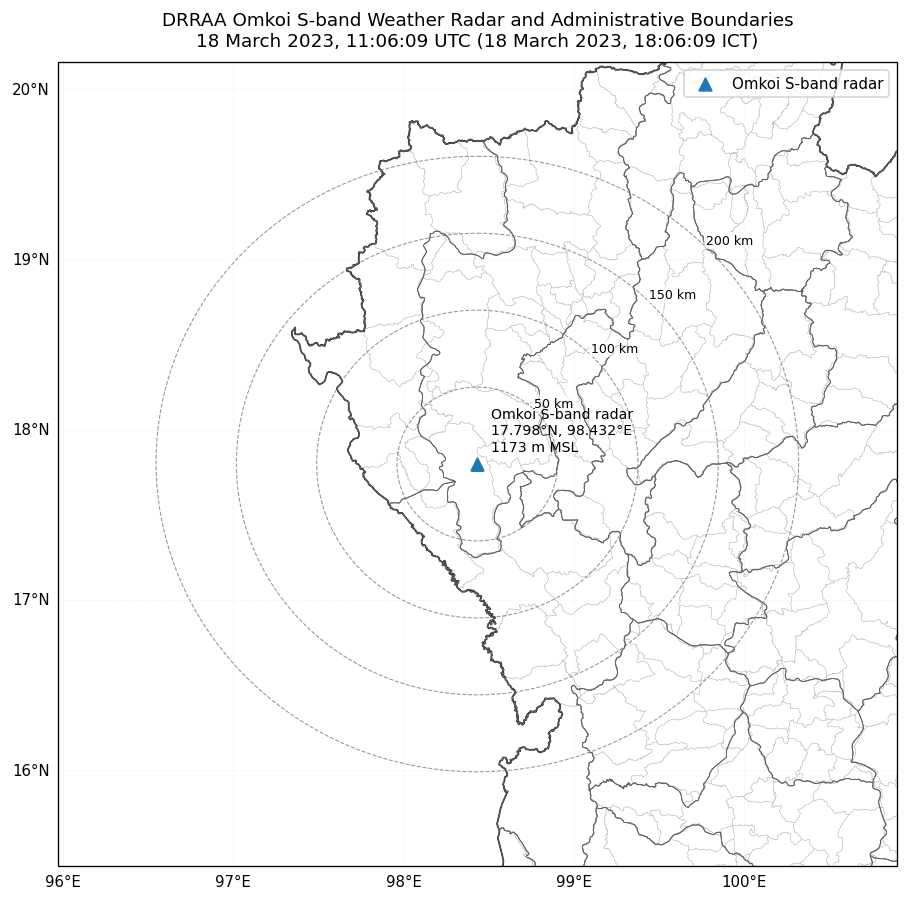

In [20]:
# CELL 19 — Publication-ready radar–GIS overview map

first_filename = RADAR_FILES[0]
first_radar = radar_objects[
    first_filename
]

radar_lat = float(
    first_radar.latitude[
        "data"
    ][0]
)

radar_lon = float(
    first_radar.longitude[
        "data"
    ][0]
)

radar_alt = float(
    first_radar.altitude[
        "data"
    ][0]
)

max_range_km = float(
    first_radar.range[
        "data"
    ][-1]
    / 1000
)

site_key, site_name = (
    first_nonempty_metadata(
        first_radar.metadata,
        [
            "site_name",
            "instrument_name",
            "radar_name",
            "site",
            "name",
        ],
    )
)

if not site_name:
    site_name = "Omkoi"

first_time_utc = (
    radar_datetime_utc(
        first_radar
    )
)

first_time_ict = (
    first_time_utc.tz_convert(
        LOCAL_TIMEZONE
    )
)

GEOD = Geod(
    ellps="WGS84"
)


def geodesic_ring(
    lon: float,
    lat: float,
    radius_km: float,
    n: int = 361,
):
    azimuth = np.linspace(
        0,
        360,
        n,
    )

    lons, lats, _ = GEOD.fwd(
        np.full(
            n,
            lon,
        ),
        np.full(
            n,
            lat,
        ),
        azimuth,
        np.full(
            n,
            radius_km
            * 1000,
        ),
    )

    return (
        np.asarray(lons),
        np.asarray(lats),
    )


extent_ring_lon, extent_ring_lat = (
    geodesic_ring(
        radar_lon,
        radar_lat,
        max_range_km,
    )
)

margin_lon = (
    extent_ring_lon.max()
    - extent_ring_lon.min()
) * 0.05

margin_lat = (
    extent_ring_lat.max()
    - extent_ring_lat.min()
) * 0.05

extent = [
    extent_ring_lon.min()
    - margin_lon,
    extent_ring_lon.max()
    + margin_lon,
    extent_ring_lat.min()
    - margin_lat,
    extent_ring_lat.max()
    + margin_lat,
]

projection = ccrs.PlateCarree()

fig = plt.figure(
    figsize=(8.2, 7.4)
)

ax = plt.axes(
    projection=projection
)

ax.set_extent(
    extent,
    crs=projection,
)

for geom in gis_objects[
    "ADM0"
].geometry:
    ax.add_geometries(
        [geom],
        crs=projection,
        facecolor="none",
        edgecolor="0.10",
        linewidth=1.0,
        zorder=2,
    )

for geom in gis_objects[
    "ADM1"
].geometry:
    ax.add_geometries(
        [geom],
        crs=projection,
        facecolor="none",
        edgecolor="0.38",
        linewidth=0.55,
        zorder=2,
    )

for geom in gis_objects[
    "ADM2"
].geometry:
    ax.add_geometries(
        [geom],
        crs=projection,
        facecolor="none",
        edgecolor="0.72",
        linewidth=0.22,
        zorder=1,
    )

standard_rings = [
    value
    for value in [
        50,
        100,
        150,
        200,
    ]
    if value < max_range_km
]

for radius_km in standard_rings:
    ring_lon, ring_lat = (
        geodesic_ring(
            radar_lon,
            radar_lat,
            radius_km,
        )
    )

    ax.plot(
        ring_lon,
        ring_lat,
        transform=projection,
        linewidth=0.65,
        linestyle="--",
        color="0.42",
        alpha=0.70,
        zorder=3,
    )

    label_lon, label_lat, _ = GEOD.fwd(
        radar_lon,
        radar_lat,
        45.0,
        radius_km * 1000,
    )

    ax.text(
        label_lon,
        label_lat,
        f"{radius_km} km",
        transform=projection,
        fontsize=7.5,
        ha="left",
        va="bottom",
        zorder=4,
        bbox={
            "facecolor": "white",
            "edgecolor": "none",
            "alpha": 0.70,
            "pad": 1.2,
        },
    )

ax.scatter(
    radar_lon,
    radar_lat,
    s=58,
    marker="^",
    transform=projection,
    zorder=5,
    label=f"{site_name} S-band radar",
)

ax.annotate(
    (
        f"{site_name} S-band radar\n"
        f"{radar_lat:.3f}°N, "
        f"{radar_lon:.3f}°E\n"
        f"{radar_alt:.0f} m MSL"
    ),
    xy=(
        radar_lon,
        radar_lat,
    ),
    xytext=(8, 8),
    textcoords="offset points",
    fontsize=8.5,
    zorder=6,
)

gridliner = ax.gridlines(
    crs=projection,
    draw_labels=True,
    linewidth=0.40,
    alpha=0.30,
    linestyle=":",
)

gridliner.top_labels = False
gridliner.right_labels = False
gridliner.xlabel_style = {
    "size": 9
}
gridliner.ylabel_style = {
    "size": 9
}

utc_text = (
    first_time_utc.strftime(
        "%d %B %Y, %H:%M:%S UTC"
    )
)

ict_text = (
    first_time_ict.strftime(
        "%d %B %Y, %H:%M:%S ICT"
    )
)

ax.set_title(
    (
        f"DRRAA {site_name} S-band Weather Radar "
        "and Administrative Boundaries\n"
        f"{utc_text} ({ict_text})"
    ),
    pad=10,
)

ax.legend(
    loc="upper right",
    frameon=True,
)

OVERVIEW_FIG = (
    PATHS["figures"]
    / (
        "01_radar_GIS_overview_"
        f"{first_time_utc.strftime('%Y%m%d_%H%M%S')}UTC.png"
    )
)

save_figure(
    fig,
    OVERVIEW_FIG,
)

plt.show()

## RESEARCH NOTE — Why this map is not yet a radar PPI

Range rings show the potential radial extent of radar sampling, but:

```text
inside maximum range
        ≠
valid meteorological observation everywhere
```

Coverage can be influenced by:

- beam geometry
- terrain blockage
- clutter
- data masking
- scan strategy
- signal attenuation / propagation
- instrument settings

ดังนั้น range circle เป็น **geometric context** ไม่ใช่ quality mask

# 22. Professional radar quicklook — validation only

Saved figure:
/content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/01/01_hail_event_PPI_validation_20230318_110609UTC_EL00.5.png


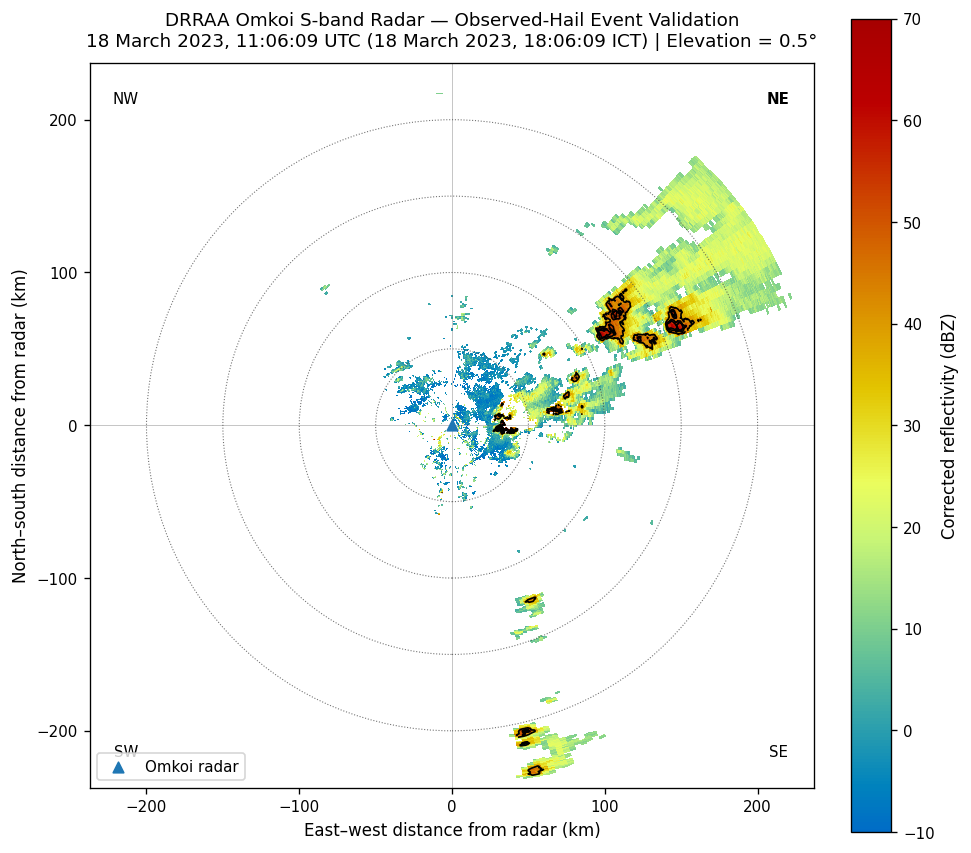

Colormap used: HomeyerRainbow


In [21]:
# CELL 20 — Lowest-sweep reflectivity quicklook
# Validation + preliminary event orientation.

available_fields = set(first_radar.fields.keys())

if "corrected_reflectivity" in available_fields:
    quicklook_field = "corrected_reflectivity"
elif "reflectivity" in available_fields:
    quicklook_field = "reflectivity"
else:
    raise RuntimeError(
        "No reflectivity field was found for the validation quicklook."
    )

def resolve_pyart_colormap(
    field_name: str,
    fallback: str = "NWSRef",
):
    candidates = []

    try:
        configured = pyart.config.get_field_colormap(
            field_name
        )

        if configured:
            candidates.append(configured)

            if configured.startswith("pyart_"):
                candidates.append(
                    configured.replace(
                        "pyart_",
                        "",
                        1,
                    )
                )

    except Exception:
        pass

    candidates.extend(
        [
            fallback,
            "Carbone11",
            "viridis",
        ]
    )

    for candidate in candidates:
        if candidate in matplotlib.colormaps:
            return candidate

    raise RuntimeError(
        "No compatible reflectivity colormap was found."
    )

quicklook_cmap = resolve_pyart_colormap(
    quicklook_field,
    fallback="NWSRef",
)

quicklook_dt_utc = radar_datetime_utc(
    first_radar
)

quicklook_dt_ict = quicklook_dt_utc.tz_convert(
    LOCAL_TIMEZONE
)

sweep = 0

fixed_angle = float(
    first_radar.fixed_angle["data"][sweep]
)

display_radar = pyart.graph.RadarDisplay(
    first_radar
)

fig = plt.figure(
    figsize=(8.0, 7.2)
)

ax = fig.add_subplot(111)

display_radar.plot_ppi(
    quicklook_field,
    sweep=sweep,
    vmin=-10,
    vmax=70,
    cmap=quicklook_cmap,
    colorbar_label="Corrected reflectivity (dBZ)",
    title="",
    ax=ax,
)

gate_x_m, gate_y_m, _ = (
    first_radar.get_gate_x_y_z(
        sweep
    )
)

sweep_zh = np.ma.asarray(
    first_radar.get_field(
        sweep,
        quicklook_field,
        copy=True,
    )
)

x_km = np.asarray(gate_x_m) / 1000.0
y_km = np.asarray(gate_y_m) / 1000.0
zh_for_contour = sweep_zh.filled(np.nan)

finite_zh = zh_for_contour[
    np.isfinite(zh_for_contour)
]

if finite_zh.size > 0:
    contour_levels = [
        level
        for level in [40.0, 50.0, 55.0]
        if (
            np.nanmin(finite_zh)
            <= level
            <= np.nanmax(finite_zh)
        )
    ]

    if contour_levels:
        contours = ax.contour(
            x_km,
            y_km,
            zh_for_contour,
            levels=contour_levels,
            colors="black",
            linewidths=1.0,
            zorder=8,
        )

        ax.clabel(
            contours,
            fmt=lambda value: f"{value:.0f} dBZ",
            inline=True,
            fontsize=7,
        )

for radius_km in [50, 100, 150, 200]:
    if radius_km >= max_range_km:
        continue

    ring = Circle(
        (0, 0),
        radius_km,
        fill=False,
        linewidth=0.65,
        linestyle=":",
        edgecolor="0.25",
        alpha=0.75,
        zorder=5,
    )

    ax.add_patch(ring)

ax.scatter(
    0,
    0,
    marker="^",
    s=40,
    zorder=9,
    label="Omkoi radar",
)

ax.axhline(
    0,
    linewidth=0.45,
    color="0.35",
    alpha=0.45,
)

ax.axvline(
    0,
    linewidth=0.45,
    color="0.35",
    alpha=0.45,
)

quadrant_offset = max_range_km * 0.90

for label, xq, yq in [
    ("NE", quadrant_offset, quadrant_offset),
    ("NW", -quadrant_offset, quadrant_offset),
    ("SE", quadrant_offset, -quadrant_offset),
    ("SW", -quadrant_offset, -quadrant_offset),
]:
    ax.text(
        xq,
        yq,
        label,
        fontsize=9,
        ha="center",
        va="center",
        fontweight=(
            "bold"
            if label == "NE"
            else "normal"
        ),
    )

ax.set_xlim(
    -max_range_km,
    max_range_km,
)

ax.set_ylim(
    -max_range_km,
    max_range_km,
)

ax.set_xlabel(
    "East–west distance from radar (km)"
)

ax.set_ylabel(
    "North–south distance from radar (km)"
)

ax.set_aspect(
    "equal",
    adjustable="box",
)

utc_text = quicklook_dt_utc.strftime(
    "%d %B %Y, %H:%M:%S UTC"
)

ict_text = quicklook_dt_ict.strftime(
    "%d %B %Y, %H:%M:%S ICT"
)

ax.set_title(
    (
        "DRRAA Omkoi S-band Radar — Observed-Hail Event Validation\n"
        f"{utc_text} ({ict_text}) | "
        f"Elevation = {fixed_angle:.1f}°"
    ),
    pad=10,
)

ax.legend(
    loc="lower left",
    frameon=True,
)

QUICKLOOK_FIG = (
    PATHS["figures"]
    / (
        "01_hail_event_PPI_validation_"
        f"{quicklook_dt_utc.strftime('%Y%m%d_%H%M%S')}UTC_"
        f"EL{fixed_angle:04.1f}.png"
    )
)

save_figure(
    fig,
    QUICKLOOK_FIG,
)

plt.show()

print("Colormap used:", quicklook_cmap)

# 22A. Preliminary strong-echo orientation ของ hail event

จากภาพเบื้องต้น กลุ่ม convective echo หลักอยู่ทาง **ตะวันออกเฉียงเหนือ (NE)** ของ Omkoi radar

เพื่อให้เป็นเชิงปริมาณ เซลล์ต่อไปจะคำนวณจาก lowest sweep ของทุก volume:

- maximum corrected reflectivity
- จำนวน gates ≥ 40, 50 และ 55 dBZ
- reflectivity-weighted centroid ของ echo ≥ 40 dBZ
- centroid range
- centroid azimuth
- 8-point compass sector

นิยาม azimuth:

```text
0° = North
90° = East
180° = South
270° = West
```

> 40/50/55 dBZ เป็น **storm-intensity thresholds** ไม่ใช่ hail-class labels.

In [22]:
# CELL 20B — Preliminary strong-echo orientation across all 10 volumes

STRONG_ECHO_THRESHOLD_DBZ = 40.0
INTENSE_ECHO_THRESHOLD_DBZ = 50.0
VERY_INTENSE_ECHO_THRESHOLD_DBZ = 55.0

def azimuth_from_xy(
    x_km,
    y_km,
):
    return (
        np.degrees(
            np.arctan2(
                x_km,
                y_km,
            )
        )
        + 360.0
    ) % 360.0

def compass_sector_8(
    azimuth_deg,
):
    labels = [
        "N",
        "NE",
        "E",
        "SE",
        "S",
        "SW",
        "W",
        "NW",
    ]

    index = int(
        (
            azimuth_deg
            + 22.5
        )
        // 45.0
    ) % 8

    return labels[index]

orientation_rows = []

for filename in RADAR_FILES:
    radar_i = radar_objects[filename]

    field_i = (
        "corrected_reflectivity"
        if "corrected_reflectivity" in radar_i.fields
        else "reflectivity"
    )

    sweep_i = 0

    zh_i = np.ma.asarray(
        radar_i.get_field(
            sweep_i,
            field_i,
            copy=True,
        )
    )

    x_i_m, y_i_m, _ = (
        radar_i.get_gate_x_y_z(
            sweep_i
        )
    )

    x_i_km = np.asarray(x_i_m) / 1000.0
    y_i_km = np.asarray(y_i_m) / 1000.0
    zh_i_values = zh_i.filled(np.nan)

    valid = (
        ~np.ma.getmaskarray(zh_i)
        & np.isfinite(zh_i_values)
    )

    strong = (
        valid
        & (
            zh_i_values
            >= STRONG_ECHO_THRESHOLD_DBZ
        )
    )

    intense = (
        valid
        & (
            zh_i_values
            >= INTENSE_ECHO_THRESHOLD_DBZ
        )
    )

    very_intense = (
        valid
        & (
            zh_i_values
            >= VERY_INTENSE_ECHO_THRESHOLD_DBZ
        )
    )

    if strong.any():
        weights = (
            zh_i_values[strong]
            - STRONG_ECHO_THRESHOLD_DBZ
            + 1.0
        )

        centroid_x_km = float(
            np.average(
                x_i_km[strong],
                weights=weights,
            )
        )

        centroid_y_km = float(
            np.average(
                y_i_km[strong],
                weights=weights,
            )
        )

        centroid_range_km = float(
            np.hypot(
                centroid_x_km,
                centroid_y_km,
            )
        )

        centroid_azimuth_deg = float(
            azimuth_from_xy(
                centroid_x_km,
                centroid_y_km,
            )
        )

        sector = compass_sector_8(
            centroid_azimuth_deg
        )

    else:
        centroid_x_km = np.nan
        centroid_y_km = np.nan
        centroid_range_km = np.nan
        centroid_azimuth_deg = np.nan
        sector = None

    orientation_rows.append({
        "filename": filename,
        "radar_datetime_UTC": radar_datetime_utc(radar_i),
        "sweep": sweep_i,
        "fixed_angle_deg": float(
            radar_i.fixed_angle["data"][sweep_i]
        ),
        "max_ZH_dBZ": (
            float(
                np.nanmax(
                    zh_i_values[valid]
                )
            )
            if valid.any()
            else np.nan
        ),
        "n_gates_ge_40dBZ": int(strong.sum()),
        "n_gates_ge_50dBZ": int(intense.sum()),
        "n_gates_ge_55dBZ": int(very_intense.sum()),
        "strong_echo_centroid_x_km": centroid_x_km,
        "strong_echo_centroid_y_km": centroid_y_km,
        "strong_echo_centroid_range_km": centroid_range_km,
        "strong_echo_centroid_azimuth_deg": centroid_azimuth_deg,
        "strong_echo_sector": sector,
    })

strong_echo_orientation = pd.DataFrame(
    orientation_rows
)

display(
    strong_echo_orientation
)

STRONG_ECHO_ORIENTATION_CSV = (
    PATHS["metadata"]
    / "01_strong_echo_orientation.csv"
)

strong_echo_orientation.to_csv(
    STRONG_ECHO_ORIENTATION_CSV,
    index=False,
)

display(
    strong_echo_orientation[
        "strong_echo_sector"
    ]
    .value_counts(
        dropna=False
    )
    .rename_axis("sector")
    .reset_index(
        name="n_volumes"
    )
)

print(
    "Saved:",
    STRONG_ECHO_ORIENTATION_CSV,
)

,filename,radar_datetime_UTC,sweep,fixed_angle_deg,max_ZH_dBZ,n_gates_ge_40dBZ,n_gates_ge_50dBZ,n_gates_ge_55dBZ,strong_echo_centroid_x_km,strong_echo_centroid_y_km,strong_echo_centroid_range_km,strong_echo_centroid_azimuth_deg,strong_echo_sector
0,20230318110609.uf.gz,2023-03-18 11:06:09+00:00,0,0.5,65.5,1286,321,136,66.102253,22.545976,69.841455,71.166658,E
1,20230318111202.uf.gz,2023-03-18 11:12:02+00:00,0,0.5,70.5,1090,313,95,92.236240,31.839669,97.577090,70.955482,E
2,20230318111802.uf.gz,2023-03-18 11:18:02+00:00,0,0.5,67.0,1254,312,94,99.614096,33.760198,105.179461,71.277974,E
3,20230318112402.uf.gz,2023-03-18 11:24:02+00:00,0,0.5,67.5,1268,345,104,98.026400,29.527010,102.376850,73.236917,E
4,20230318113002.uf.gz,2023-03-18 11:30:02+00:00,0,0.5,63.5,1252,374,127,90.985266,21.784096,93.556750,76.535452,E
5,20230318113602.uf.gz,2023-03-18 11:36:02+00:00,0,0.5,65.0,1223,360,104,90.036147,21.192076,92.496551,76.755199,E
6,20230318114202.uf.gz,2023-03-18 11:42:02+00:00,0,0.5,61.5,1217,261,77,90.800195,26.877040,94.694513,73.511141,E
7,20230318114802.uf.gz,2023-03-18 11:48:02+00:00,0,0.5,62.0,1113,227,62,92.793310,24.451557,95.960809,75.237807,E
8,20230318115402.uf.gz,2023-03-18 11:54:02+00:00,0,0.5,64.5,1158,229,48,102.043293,24.631685,104.974062,76.429276,E
9,20230318120002.uf.gz,2023-03-18 12:00:02+00:00,0,0.5,61.5,1228,220,51,99.924337,26.273472,103.320707,75.268453,E


,sector,n_volumes
0,E,10


Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/02_metadata/01_strong_echo_orientation.csv


In [23]:
# CELL 20C — Event-orientation summary

orientation_valid = (
    strong_echo_orientation.dropna(
        subset=[
            "strong_echo_centroid_azimuth_deg"
        ]
    )
)

if orientation_valid.empty:
    DOMINANT_STRONG_ECHO_SECTOR = None
    MEDIAN_STRONG_ECHO_AZIMUTH_DEG = np.nan
    MEDIAN_STRONG_ECHO_RANGE_KM = np.nan

else:
    sector_counts = (
        orientation_valid[
            "strong_echo_sector"
        ]
        .value_counts()
    )

    DOMINANT_STRONG_ECHO_SECTOR = (
        sector_counts.index[0]
    )

    MEDIAN_STRONG_ECHO_AZIMUTH_DEG = float(
        orientation_valid[
            "strong_echo_centroid_azimuth_deg"
        ].median()
    )

    MEDIAN_STRONG_ECHO_RANGE_KM = float(
        orientation_valid[
            "strong_echo_centroid_range_km"
        ].median()
    )

event_orientation_summary = pd.DataFrame({
    "metric": [
        "dominant_strong_echo_sector",
        "median_strong_echo_centroid_azimuth_deg",
        "median_strong_echo_centroid_range_km",
        "maximum_lowest_sweep_ZH_dBZ",
        "maximum_number_of_gates_ge_50dBZ",
        "maximum_number_of_gates_ge_55dBZ",
    ],
    "value": [
        DOMINANT_STRONG_ECHO_SECTOR,
        MEDIAN_STRONG_ECHO_AZIMUTH_DEG,
        MEDIAN_STRONG_ECHO_RANGE_KM,
        float(
            strong_echo_orientation[
                "max_ZH_dBZ"
            ].max()
        ),
        int(
            strong_echo_orientation[
                "n_gates_ge_50dBZ"
            ].max()
        ),
        int(
            strong_echo_orientation[
                "n_gates_ge_55dBZ"
            ].max()
        ),
    ],
})

display(
    event_orientation_summary
)

EVENT_ORIENTATION_SUMMARY_CSV = (
    PATHS["metadata"]
    / "01_event_orientation_summary.csv"
)

event_orientation_summary.to_csv(
    EVENT_ORIENTATION_SUMMARY_CSV,
    index=False,
)

print(
    "Preliminary event orientation:",
    DOMINANT_STRONG_ECHO_SECTOR,
)

if DOMINANT_STRONG_ECHO_SECTOR == "NE":
    print(
        "Computed strong-echo orientation is consistent "
        "with the visually observed NE storm cluster."
    )
else:
    print(
        "Computed dominant sector is not NE. "
        "Inspect all volumes before fixing later cross-section geometry."
    )

,metric,value
0,dominant_strong_echo_sector,E
1,median_strong_echo_centroid_azimuth_deg,74.374474
2,median_strong_echo_centroid_range_km,96.76895
3,maximum_lowest_sweep_ZH_dBZ,70.5
4,maximum_number_of_gates_ge_50dBZ,374
5,maximum_number_of_gates_ge_55dBZ,136


Preliminary event orientation: E
Computed dominant sector is not NE. Inspect all volumes before fixing later cross-section geometry.


## CORE — Do not over-interpret the quicklook

ภาพข้างต้นใช้ตอบคำถามเพียงว่า:

- radar file เปิดได้หรือไม่?
- reflectivity field มี spatial structure หรือไม่?
- sweep 0 plot ได้หรือไม่?
- range และ orientation ดูสมเหตุสมผลหรือไม่?

Notebook 01 **ยังไม่สรุป** ว่า echo ใดเป็น severe storm, hail, clutter หรือ rainfall rate

หัวข้อการตีความ PPI จะเริ่มใน Notebook 02

# 23. Create compact metadata tables for future Notebooks

In [24]:
# CELL 21 — Compact course metadata

field_summary = (
    radar_field_inventory
    .groupby(
        "field",
        as_index=False,
    )
    .agg(
        n_volumes=(
            "filename",
            "nunique",
        ),
        mean_masked_fraction=(
            "masked_fraction",
            "mean",
        ),
        median_of_field_medians=(
            "median",
            "median",
        ),
        overall_p05=(
            "p05",
            "min",
        ),
        overall_p95=(
            "p95",
            "max",
        ),
    )
)

FIELD_SUMMARY_CSV = (
    PATHS["metadata"]
    / "01_radar_field_summary.csv"
)

field_summary.to_csv(
    FIELD_SUMMARY_CSV,
    index=False,
)

display(field_summary)

print("Saved:")
print(FIELD_SUMMARY_CSV)

,field,n_volumes,mean_masked_fraction,median_of_field_medians,overall_p05,overall_p95
0,corrected_differential_reflectivity,10,0.952065,0.620,-1.380,7.51
1,corrected_reflectivity,10,0.944087,12.000,-11.500,39.50
2,cross_correlation_ratio,10,0.907729,0.952,0.401,1.00
3,differential_phase,10,0.968756,7.790,0.000,360.00
4,reflectivity,10,0.831765,5.500,-10.500,37.00
5,specific_differential_phase,10,0.968756,0.000,-0.390,0.48
6,spectrum_width,10,0.916838,1.935,0.520,4.39
7,velocity,10,0.909515,2.760,-12.490,13.28


Saved:
/content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/02_metadata/01_radar_field_summary.csv


# 24. Final readiness checks

In [25]:
# CELL 22 — Acceptance / readiness table

checks = []

def add_check(
    item,
    observed,
    expected,
    passed,
    note="",
):
    checks.append({
        "item": item,
        "observed": observed,
        "expected": expected,
        "status": (
            "PASS"
            if passed
            else "FAIL"
        ),
        "note": note,
    })


add_check(
    "Radar source file count",
    len(
        list(
            PATHS["radar"].glob(
                "*.uf.gz"
            )
        )
    ),
    len(RADAR_FILES),
    len(
        list(
            PATHS["radar"].glob(
                "*.uf.gz"
            )
        )
    )
    == len(RADAR_FILES),
)

add_check(
    "Radar gzip integrity",
    int(
        (
            gzip_integrity[
                "gzip_integrity"
            ]
            == "PASS"
        ).sum()
    ),
    len(RADAR_FILES),
    (
        gzip_integrity[
            "gzip_integrity"
        ]
        == "PASS"
    ).all(),
)

add_check(
    "Radar volumes readable",
    len(
        radar_objects
    ),
    len(
        RADAR_FILES
    ),
    len(
        radar_objects
    )
    == len(
        RADAR_FILES
    ),
)

add_check(
    "Core reflectivity / velocity / spectrum-width contract",
    int(
        field_contract[
            "PASS"
        ].sum()
    ),
    len(
        field_contract
    ),
    field_contract[
        "PASS"
    ].all(),
)

add_check(
    "Radar-site coordinate consistency",
    (
        f"lat spread={lat_spread:.5f}°, "
        f"lon spread={lon_spread:.5f}°"
    ),
    "<= 0.01°",
    (
        lat_spread <= 0.01
        and lon_spread <= 0.01
    ),
)

add_check(
    "Expected one-hour sample volume count",
    len(
        radar_volume_inventory
    ),
    10,
    len(
        radar_volume_inventory
    )
    == 10,
)

median_interval = (
    float(
        valid_intervals.median()
    )
    if len(
        valid_intervals
    ) > 0
    else np.nan
)

add_check(
    "Nominal scan interval",
    (
        f"{median_interval:.2f} min"
        if np.isfinite(
            median_interval
        )
        else "NaN"
    ),
    "approximately 6 min",
    (
        np.isfinite(
            median_interval
        )
        and abs(
            median_interval
            - 6
        ) <= 0.5
    ),
    (
        "Based on filename sequence; "
        "time-zone interpretation remains separate."
    ),
)

add_check(
    "GIS source count",
    len(
        gis_objects
    ),
    3,
    len(
        gis_objects
    )
    == 3,
)

add_check(
    "Canonical GIS CRS",
    "; ".join(
        sorted(
            {
                str(
                    gdf.crs
                )
                for gdf
                in gis_objects.values()
            }
        )
    ),
    "EPSG:4326",
    all(
        gdf.crs.to_epsg()
        == 4326
        for gdf
        in gis_objects.values()
    ),
)

add_check(
    "Canonical GIS geometry validity",
    int(
        gis_inventory[
            "invalid_after"
        ].sum()
    ),
    0,
    int(
        gis_inventory[
            "invalid_after"
        ].sum()
    )
    == 0,
)

add_check(
    "UF time reference explicitly UTC",
    bool(
        time_table[
            "time_units_explicitly_UTC"
        ].all()
    ),
    True,
    bool(
        time_table[
            "time_units_explicitly_UTC"
        ].all()
    ),
    (
        "Verified from UF time-unit strings containing an explicit UTC marker."
    ),
)

add_check(
    "Filename time matches UF radar time",
    float(
        time_table[
            "filename_minus_radar_time_s"
        ].abs().max()
    ),
    "0 s",
    bool(
        np.allclose(
            time_table[
                "filename_minus_radar_time_s"
            ].dropna(),
            0.0,
        )
    ),
    (
        "This justifies treating the frozen teaching filenames as UTC."
    ),
)

add_check(
    "Radar band metadata",
    RADAR_BAND,
    "S",
    RADAR_BAND
    == "S",
    (
        "Band supplied by instructor/site information."
    ),
)


add_check(
    "Active event type",
    EVENT_TYPE,
    "observed_hail",
    EVENT_TYPE == "observed_hail",
    (
        "Event-level hail status supplied by instructor; "
        "not inferred from reflectivity alone."
    ),
)

add_check(
    "Strong-echo orientation diagnostic",
    DOMINANT_STRONG_ECHO_SECTOR,
    "diagnostic available",
    DOMINANT_STRONG_ECHO_SECTOR is not None,
    (
        "Based on lowest-sweep reflectivity gates >= 40 dBZ."
    ),
)

readiness = pd.DataFrame(
    checks
)

display(readiness)

READINESS_CSV = (
    PATHS["metadata"]
    / "01_readiness_check.csv"
)

readiness.to_csv(
    READINESS_CSV,
    index=False,
)

READY = (
    readiness[
        "status"
    ]
    == "PASS"
).all()

print()
print(
    "DRRAA RADAR–GIS COURSE DATA READY"
    if READY
    else "DATASET REQUIRES REVIEW BEFORE NOTEBOOK 02"
)

print()
print("Saved:")
print(READINESS_CSV)

,item,observed,expected,status,note
0,Radar source file count,10,10,PASS,
1,Radar gzip integrity,10,10,PASS,
2,Radar volumes readable,10,10,PASS,
3,Core reflectivity / velocity / spectrum-width ...,30,30,PASS,
4,Radar-site coordinate consistency,"lat spread=0.00000°, lon spread=0.00000°",<= 0.01°,PASS,
5,Expected one-hour sample volume count,10,10,PASS,
6,Nominal scan interval,6.00 min,approximately 6 min,PASS,Based on filename sequence; time-zone interpre...
7,GIS source count,3,3,PASS,
8,Canonical GIS CRS,EPSG:4326,EPSG:4326,PASS,
9,Canonical GIS geometry validity,0,0,PASS,



DRRAA RADAR–GIS COURSE DATA READY

Saved:
/content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/02_metadata/01_readiness_check.csv


# 25. Save setup-status log

In [26]:
# CELL 23 — setup_status.json

SETUP_STATUS_JSON = (
    PATHS["logs"]
    / "01_setup_status.json"
)

setup_status = {
    "ready": bool(READY),
    "created_utc": utc_now_iso(),
    "dataset_label": COURSE_DATASET_LABEL,
    "event": {
        "event_id": EVENT_ID,
        "event_label": EVENT_LABEL,
        "event_type": EVENT_TYPE,
        "event_status_source": EVENT_STATUS_SOURCE,
        "github_radar_subdir": GITHUB_RADAR_SUBDIR,
        "dominant_strong_echo_sector": DOMINANT_STRONG_ECHO_SECTOR,
        "median_strong_echo_centroid_azimuth_deg": (
            MEDIAN_STRONG_ECHO_AZIMUTH_DEG
            if np.isfinite(MEDIAN_STRONG_ECHO_AZIMUTH_DEG)
            else None
        ),
        "median_strong_echo_centroid_range_km": (
            MEDIAN_STRONG_ECHO_RANGE_KM
            if np.isfinite(MEDIAN_STRONG_ECHO_RANGE_KM)
            else None
        ),
    },
    "radar_site_name": site_name,
    "radar_band": RADAR_BAND,
    "time_reference": {
        "canonical_timezone": CANONICAL_TIMEZONE,
        "local_timezone": LOCAL_TIMEZONE,
        "local_time_label": LOCAL_TIME_LABEL,
        "utc_verified": bool(
            time_table[
                "time_units_explicitly_UTC"
            ].all()
        ),
        "filename_matches_radar_time": bool(
            np.allclose(
                time_table[
                    "filename_minus_radar_time_s"
                ].dropna(),
                0.0,
            )
        ),
        "utc_start": str(
            radar_volume_inventory[
                "radar_datetime_UTC"
            ].min()
        ),
        "utc_end": str(
            radar_volume_inventory[
                "radar_datetime_UTC"
            ].max()
        ),
        "ict_start": str(
            radar_volume_inventory[
                "radar_datetime_ICT"
            ].min()
        ),
        "ict_end": str(
            radar_volume_inventory[
                "radar_datetime_ICT"
            ].max()
        ),
    },
    "n_radar_volumes": len(
        radar_objects
    ),
    "median_radar_interval_min": (
        median_interval
        if np.isfinite(
            median_interval
        )
        else None
    ),
    "radar_latitude_deg": radar_lat,
    "radar_longitude_deg": radar_lon,
    "radar_altitude_m_MSL": radar_alt,
    "max_range_km": max_range_km,
    "canonical_gis": str(
        CANONICAL_GPKG
    ),
    "metadata_files": {
        "download_inventory": str(
            DOWNLOAD_INVENTORY_CSV
        ),
        "radar_volume_inventory": str(
            RADAR_VOLUME_CSV
        ),
        "radar_time_inventory": str(
            TIME_CSV
        ),
        "radar_scan_strategy": str(
            SCAN_CSV
        ),
        "radar_field_inventory": str(
            FIELD_CSV
        ),
        "field_consistency": str(
            FIELD_CONSISTENCY_CSV
        ),
        "gis_inventory": str(
            GIS_CSV
        ),
        "readiness": str(
            READINESS_CSV
        ),
        "first_volume_nonempty_metadata": str(
            RADAR_METADATA_CSV
        ),
        "strong_echo_orientation": str(
            STRONG_ECHO_ORIENTATION_CSV
        ),
        "event_orientation_summary": str(
            EVENT_ORIENTATION_SUMMARY_CSV
        ),
    },
    "figures": {
        "radar_gis_overview": str(
            OVERVIEW_FIG
        ),
        "reflectivity_quicklook": str(
            QUICKLOOK_FIG
        ),
    },
    "software_versions": SOFTWARE_VERSIONS,
}

with SETUP_STATUS_JSON.open(
    "w",
    encoding="utf-8",
) as stream:
    json.dump(
        setup_status,
        stream,
        ensure_ascii=False,
        indent=2,
        default=str,
    )

print("Saved:")
print(SETUP_STATUS_JSON)

Saved:
/content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/99_logs/01_setup_status.json


# 26. สิ่งที่ Notebook 01 ตั้งใจยังไม่ทำ

แม้ชุดนี้เป็น **observed hail event** แต่ Notebook 01 ยังไม่ทำ hail classification, MESH, HSDA, HDR, VIL/VILD, echo top, vertical cross section หรือ hydrometeor classification.

สิ่งที่เพิ่มมีเพียง **preliminary strong-echo orientation** เพื่อบันทึก geometry ของ storm sector สำหรับ Notebook 02–08.

> `Strong echo in the NE sector ≠ hail proven by radar`

# 27. Exercises

### Exercise 1 — Radar structure
เลือก radar volume 1 ไฟล์ แล้วรายงาน:

- `nsweeps`
- `nrays`
- `ngates`
- fixed angles
- gate spacing
- maximum range

อธิบายว่าตัวเลขแต่ละตัวหมายถึงอะไรทาง radar geometry

### Exercise 2 — UTC and Thailand local time
ใช้ UF time units และตารางเวลาอธิบายว่า:

```text
18 March 2023, 18:00 UTC
```

ตรงกับวันและเวลาใดในประเทศไทย

จากนั้นอธิบายว่าเหตุใด derived-data filename ควรใช้ UTC เป็น canonical time

### Exercise 3 — Scan strategy
สร้างรายการ elevation angles ทั้ง 14 sweeps แล้วตอบ:

- lowest elevation?
- highest elevation?
- elevation spacing คงที่หรือไม่?
- scan strategy นี้มีประโยชน์ต่อ vertical severe-storm analysis อย่างไร?

### Exercise 4 — Field consistency
เลือก 4 fields:

- corrected reflectivity
- velocity
- spectrum width
- cross-correlation ratio

ตรวจว่า field ใดมีครบทุก 10 volumes

### Exercise 5 — GIS
ตรวจ ADM1 และ ADM2:

- number of features
- CRS
- geometry types
- administrative-name field

อธิบายข้อจำกัดของ `ADM2_simplified`

### Exercise 6 — Publication practice
เปิด `01_radar_GIS_overview_*.png` และ `01_PPI_validation_*.png` แล้วตรวจว่า:

- UTC และ ICT ระบุชัดหรือไม่
- elevation angle ระบุชัดหรือไม่
- units อ่านได้หรือไม่
- contextual lines เด่นเกิน radar data หรือไม่
- title ยาวเกินไปสำหรับ journal column หรือไม่

จากนั้นเสนอ **หนึ่งการปรับปรุงสำหรับ conference figure** และ **หนึ่งการปรับปรุงสำหรับ journal figure**

# Key messages

1. ชุดข้อมูลนี้เป็น observed-hail event ตามข้อมูลเหตุการณ์ที่ผู้สอนยืนยัน
2. Event label ไม่ใช่ pixel-level hail classification
3. เวลาใน filename ต้องตรวจเทียบกับ UF internal time
4. Scan strategy และ field availability ต้องตรวจใหม่เมื่อเปลี่ยน event
5. Strong reflectivity ไม่ใช่หลักฐาน hail โดยตัวมันเอง
6. Strong-echo orientation ควรคำนวณจากข้อมูล ไม่ใช่กำหนดจากการมองภาพอย่างเดียว
7. สำหรับ event นี้ code จะตรวจว่าสอดคล้องกับ NE sector หรือไม่
8. GIS canonical layer ใช้ร่วมข้าม events ได้
9. Radar outputs/metadata ควรแยก event directory เพื่อ reproducibility
10. Notebook 02 จะวิเคราะห์ PPI/velocity/spectrum width และ strong-core evolution ต่อ

---

## Notebook 01 — Teaching Version 1.0

This version incorporates the first full Google Colab validation of the Omkoi teaching dataset:

- 10/10 UF files readable
- exact 6-min sequence
- UTC verified from UF time units
- filename timestamps match UF timestamps
- 14 sweeps per volume
- fixed-angle range 0.5°–19.5°
- 500-m gate spacing
- 237.25-km maximum range
- Nyquist velocity 16.7 m s⁻¹
- 8 radar fields present in all 10 volumes
- radar location invariant across volumes
- ADM0 = 1 feature
- ADM1 = 77 features
- ADM2 simplified = 928 features
- canonical GIS CRS = EPSG:4326
- canonical geometries valid

The Notebook is therefore designed to serve as the stable input foundation for Notebook 02–09.